# Машинне навчання — Питання та Відповіді

Кожен розділ містить запитання, стислу відповідь і готовий до запуску приклад коду.

**Теми:**
1. Основи
2. Передобробка даних
3. Алгоритми класифікації
4. Алгоритми регресії
5. Оцінка моделей — Класифікація
6. Оцінка моделей — Регресія
7. Налаштування гіперпараметрів та перенавчання
8. Теорія ймовірностей і статистика
9. Просунуті теми
10. Конструювання ознак
10. Лінійна алгебра для МН


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer, load_diabetes, make_classification, make_regression

# Shared toy datasets used across examples
iris = load_iris(as_frame=True)
X_iris, y_iris = iris.data, iris.target

cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = cancer.data, cancer.target

diabetes = load_diabetes(as_frame=True)
X_diab, y_diab = diabetes.data, diabetes.target

print('Iris shape:    ', X_iris.shape)
print('Cancer shape:  ', X_cancer.shape)
print('Diabetes shape:', X_diab.shape)

Iris shape:     (150, 4)
Cancer shape:   (569, 30)
Diabetes shape: (442, 10)


---
# 1. Основи

## Q1: Яка різниця між навчанням з учителем та без учителя?

**З учителем (Supervised)** — кожен навчальний приклад має мітку (цільову змінну). Модель навчається відображати входи → виходи.
- Класифікація: мітка — категорія (спам / не спам)
- Регресія: мітка — число (ціна будинку)

**Без учителя (Unsupervised)** — мітки відсутні. Модель знаходить структуру в самих даних.
- Кластеризація: групування схожих прикладів (K-Means)
- Зниження розмірності: стиснення ознак (PCA)


In [2]:
from sklearn.cluster import KMeans

# --- Supervised: predict iris species (label exists) ---
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_iris, y_iris)
print('Supervised accuracy:', round(clf.score(X_iris, y_iris), 3))

# --- Unsupervised: cluster iris without using labels ---
km = KMeans(n_clusters=3, random_state=42, n_init='auto')
km.fit(X_iris)
print('Unsupervised cluster labels:', np.unique(km.labels_))

Supervised accuracy: 0.973


Unsupervised cluster labels: [0 1 2]


## Q2: Що таке розбивка на навчальну та тестову вибірки і навіщо вона потрібна?

Ми відкладаємо частину даних, яку модель не бачить під час навчання. Це дає чесну оцінку того, наскільки добре модель узагальнює нові дані.

Без цього точність, виміряна на навчальних даних, є завищеною — модель могла їх просто «запам'ятати».

**`stratify=y`** зберігає пропорції класів в обох вибірках — завжди використовуйте це для класифікації.


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

print('Train size:', X_train.shape[0])
print('Test  size:', X_test.shape[0])

# Class proportions should be roughly equal
print('Train class ratio:', y_train.value_counts(normalize=True).round(2).to_dict())
print('Test  class ratio:', y_test.value_counts(normalize=True).round(2).to_dict())

Train size: 455
Test  size: 114
Train class ratio: {1: 0.63, 0: 0.37}
Test  class ratio: {1: 0.63, 0: 0.37}


## Q3: Що таке крос-валідація і коли її застосовувати?

K-fold CV розбиває дані на K частин. Модель навчається K разів — щоразу одна частина є тестовою, решта — навчальною. Підсумковий показник = середнє по K запускам.

**Навіщо:** одне розбивання може бути вдалим або невдалим залежно від того, які зразки потрапили куди. CV дає стабільнішу оцінку з меншою дисперсією.

**Коли:** використовуйте CV для вибору моделі та налаштування гіперпараметрів. Відкладену тестову вибірку використовуйте лише для фінальної оцінки.


CV scores per fold: [0.912 0.895 0.939 0.956 0.894]
Mean: 0.919  Std: 0.025


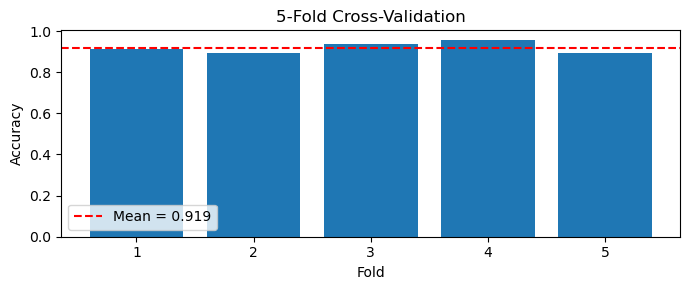

In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
scores = cross_val_score(clf, X_cancer, y_cancer, cv=5, scoring='accuracy')

print('CV scores per fold:', scores.round(3))
print(f'Mean: {scores.mean():.3f}  Std: {scores.std():.3f}')

# Visualise fold-by-fold variance
plt.figure(figsize=(7, 3))
plt.bar(range(1, 6), scores)
plt.axhline(scores.mean(), color='red', linestyle='--', label=f'Mean = {scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation')
plt.legend()
plt.tight_layout()
plt.show()

## Q3b: Як виглядає типовий пайплайн ML-проєкту?

```
Сирі дані
   │
   ▼
1. EDA  ──────────────── розуміння розподілів, пропущених значень, кореляцій
   │
   ▼
2. Конструювання ознак ─ створення/перетворення ознак (log, відношення, бінінг)
   │
   ▼
3. Передобробка ───────── імпутація → масштабування → кодування (всередині Pipeline!)
   │
   ▼
4. Вибір моделі ───────── порівняння кількох алгоритмів через крос-валідацію
   │
   ▼
5. Налаштування гіперпараметрів ─ GridSearchCV / RandomizedSearchCV
   │
   ▼
6. Фінальна оцінка ──── запускається рівно один раз на відкладеній тестовій вибірці
   │
   ▼
7. Розгортання ──────── серіалізація пайплайну (joblib), подача передбачень
```

**Золоте правило:** тестова вибірка торкається **рівно один раз** — наприкінці.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib, tempfile, os

# ── Step 1: Load & EDA ───────────────────────────────────────────────────────
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Class balance: {y.value_counts().to_dict()}')
print(f'Missing values: {X.isnull().sum().sum()}')

# ── Step 2: Train-test split (done FIRST, before any fitting) ────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# ── Step 3: Build pipeline (preprocessing + model) ───────────────────────────
pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

# ── Step 4: Model selection via cross-validation ─────────────────────────────
cv_score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1').mean()
print(f'\nCV F1 (default RF): {cv_score:.4f}')

# ── Step 5: Hyperparameter tuning ────────────────────────────────────────────
param_grid = {'clf__n_estimators': [50, 100], 'clf__max_depth': [None, 5]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
print(f'Best params: {grid.best_params_}')
print(f'Best CV F1:  {grid.best_score_:.4f}')

# ── Step 6: Final evaluation on test set (only once!) ────────────────────────
y_pred = grid.predict(X_test)
print(f'\nTest set classification report:')
print(classification_report(y_test, y_pred, target_names=['Malignant','Benign']))

# ── Step 7: Serialize pipeline ───────────────────────────────────────────────
tmp = tempfile.mktemp(suffix='.pkl')
joblib.dump(grid.best_estimator_, tmp)
loaded_pipe = joblib.load(tmp)
print(f'Serialized and reloaded pipeline predictions match: '
      f'{(loaded_pipe.predict(X_test) == y_pred).all()}')
os.unlink(tmp)


Dataset: 569 samples, 30 features
Class balance: {1: 357, 0: 212}
Missing values: 0



CV F1 (default RF): 0.9634


Best params: {'clf__max_depth': None, 'clf__n_estimators': 100}
Best CV F1:  0.9634

Test set classification report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Serialized and reloaded pipeline predictions match: True


---
# 2. Передобробка даних

## Q4: Як обробляти пропущені значення?

`SimpleImputer` заповнює пропуски обраною статистикою:
- `'mean'` — підходить для приблизно симетричних числових стовпців
- `'median'` — краще, коли є викиди
- `'most_frequent'` — для категоріальних стовпців
- `'constant'` — заповнення фіксованим значенням

Завжди навчайте імпутер **лише на навчальних даних**, потім застосовуйте до обох вибірок.


In [6]:
from sklearn.impute import SimpleImputer

# Synthetic data with missing values
data = pd.DataFrame({
    'age':    [25, np.nan, 35, 40, np.nan],
    'salary': [50000, 60000, np.nan, 80000, 55000],
    'city':   ['NY', 'LA', np.nan, 'NY', 'LA']
})
print('Before:\n', data)

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

data[['age', 'salary']] = num_imputer.fit_transform(data[['age', 'salary']])
data[['city']] = cat_imputer.fit_transform(data[['city']])

print('\nAfter:\n', data)

Before:
     age   salary city
0  25.0  50000.0   NY
1   NaN  60000.0   LA
2  35.0      NaN  NaN
3  40.0  80000.0   NY
4   NaN  55000.0   LA

After:
     age   salary city
0  25.0  50000.0   NY
1  35.0  60000.0   LA
2  35.0  57500.0   LA
3  40.0  80000.0   NY
4  35.0  55000.0   LA


## Q5: Яка різниця між StandardScaler і MinMaxScaler?

| Масштабувальник | Формула | Діапазон виходу | Використовувати коли |
|---|---|---|---|
| `StandardScaler` | `(x - mean) / std` | ~[-3, 3] | Дані приблизно нормальні; SVM, KNN |
| `MinMaxScaler` | `(x - min) / (max - min)` | [0, 1] | Нейронні мережі, потрібен обмежений діапазон |

**Обидва треба навчати лише на навчальних даних.**
KNN та SVM чутливі до масштабу. Дерева рішень та Random Forest — ні.


In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sample = np.array([[10], [20], [30], [1000]])  # outlier at 1000

std  = StandardScaler().fit_transform(sample)
minmax = MinMaxScaler().fit_transform(sample)

df_cmp = pd.DataFrame({'original': sample.ravel(),
                        'StandardScaler': std.ravel().round(2),
                        'MinMaxScaler': minmax.ravel().round(2)})
print(df_cmp)
# Notice: MinMaxScaler squeezes 10/20/30 near 0 because of the outlier

   original  StandardScaler  MinMaxScaler
0        10           -0.60          0.00
1        20           -0.58          0.01
2        30           -0.55          0.02
3      1000            1.73          1.00


## Q5b: Що таке нормалізація і як вона впливає на ML-моделі?

«Нормалізація» — загальний термін для будь-якого перетворення, що змінює масштаб ознак. Три поширені типи:

| Техніка | Формула | Результат | Використовувати коли |
|---|---|---|---|
| **Min-Max** | (x − min) / (max − min) | [0, 1] | Нейронні мережі; потрібен обмежений діапазон |
| **Z-оцінка (стандартизація)** | (x − μ) / σ | mean=0, std=1 | KNN, SVM, Логістична регресія |
| **L2-нормалізація** | x / \|\|x\|\| | одинична норма на зразок | Текст/NLP, косинусна подібність |

**Які алгоритми чутливі?**
- **Чутливі:** KNN, SVM, Логістична регресія, Ridge/Lasso, Нейронні мережі
- **Нечутливі:** Дерево рішень, Random Forest, Gradient Boosting — вони використовують пороги, а не відстані

**Завжди навчайте на тренуванні, перетворюйте обидві вибірки.** `Pipeline` робить це автоматично.


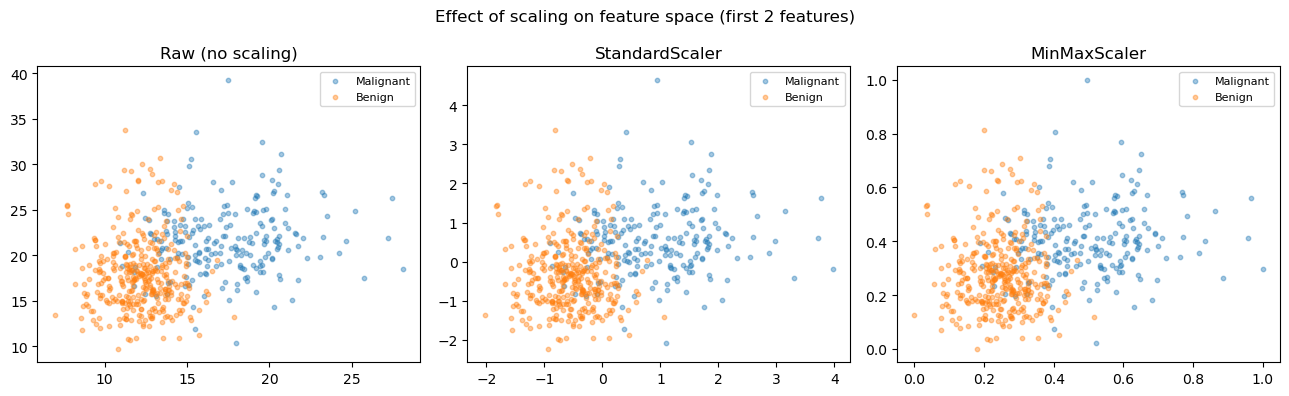

KNN CV accuracy by scaling:
  No scaling     : 0.9262
  StandardScaler : 0.9701
  MinMaxScaler   : 0.9701


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

# Visual: effect of scaling on two features with very different ranges
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = ['Raw (no scaling)', 'StandardScaler', 'MinMaxScaler']
datasets = [X[:, :2],
            StandardScaler().fit_transform(X[:, :2]),
            MinMaxScaler().fit_transform(X[:, :2])]

for ax, Xs, label in zip(axes, datasets, labels):
    ax.scatter(Xs[y==0, 0], Xs[y==0, 1], alpha=0.4, s=10, label='Malignant')
    ax.scatter(Xs[y==1, 0], Xs[y==1, 1], alpha=0.4, s=10, label='Benign')
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.suptitle('Effect of scaling on feature space (first 2 features)')
plt.tight_layout()
plt.show()

# Impact on KNN accuracy
print('KNN CV accuracy by scaling:')
for name, scaler in [('No scaling',    None),
                      ('StandardScaler', StandardScaler()),
                      ('MinMaxScaler',   MinMaxScaler())]:
    steps = [('scl', scaler), ('knn', KNeighborsClassifier(n_neighbors=7))] if scaler else             [('knn', KNeighborsClassifier(n_neighbors=7))]
    pipe = Pipeline(steps)
    score = cross_val_score(pipe, X, y, cv=5).mean()
    print(f'  {name:15s}: {score:.4f}')


## Q5c: Що таке кореляція Пірсона і як її використовувати в ML?

Коефіцієнт Пірсона **r** вимірює **лінійний** зв'язок між двома змінними.

### Формула

$$r = \frac{\text{cov}(X,\, Y)}{\sigma_X \cdot \sigma_Y}$$

Або еквівалентно:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

### Тлумачення r

| Значення r | Тлумачення |
|---|---|
| **+1** | Ідеальний позитивний лінійний зв'язок |
| **−1** | Ідеальний негативний лінійний зв'язок |
| **0** | Лінійного зв'язку немає (нелінійний може існувати!) |
| \|r\| > 0.8 | Сильна кореляція |
| 0.5 < \|r\| ≤ 0.8 | Помірна кореляція |
| \|r\| ≤ 0.5 | Слабка кореляція |

### Застосування в ML

1. **Відбір ознак** — видалити одну з двох ознак з \|r\| > 0.9 (надлишкова)
2. **Кореляція з ціллю** — знайти найбільш передбачувальні ознаки
3. **Мультиколінеарність** — коінтегровані ознаки роздувають коефіцієнти лінійних моделей

### Обмеження

> Пірсон виявляє лише **лінійні** залежності.  
> Для монотонних нелінійних — **ρ Спірмена**, для довільних залежностей — **взаємна інформація**.


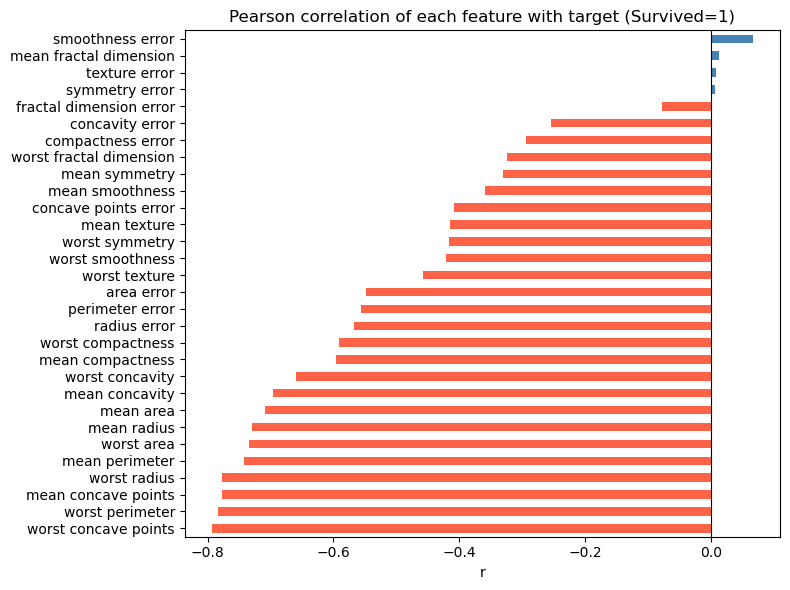

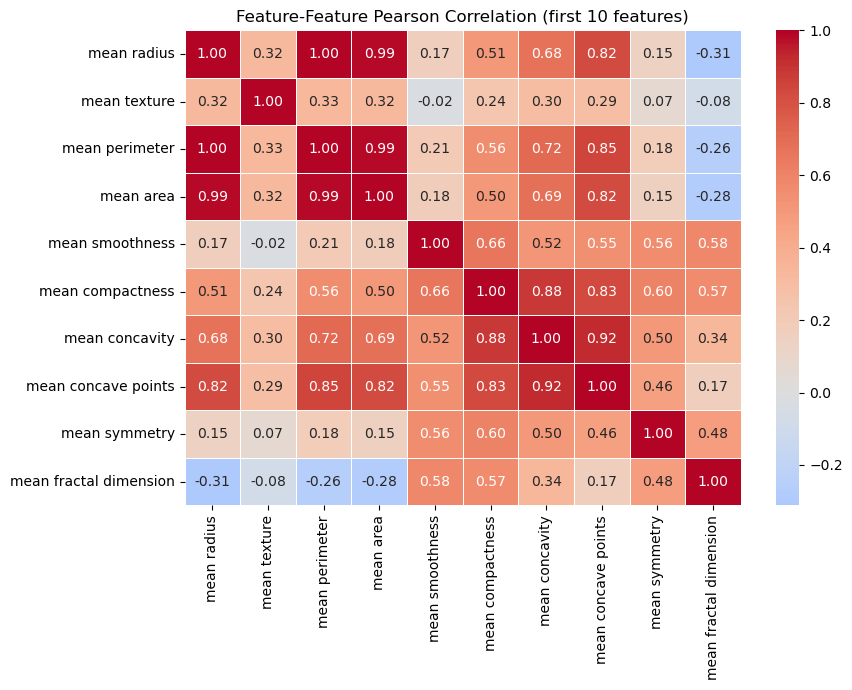

           Pearson r    Spearman rho
Linear              0.9781        0.9783
Nonlinear (exp)     0.9009        0.9916
Spearman handles nonlinear monotonic relationships better


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

# ── 1. Correlation with target ────────────────────────────────────────────────
target_corr = X.corrwith(y).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
target_corr.plot(kind='barh', color=['tomato' if v < 0 else 'steelblue' for v in target_corr], ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation of each feature with target (Survived=1)')
ax.set_xlabel('r')
plt.tight_layout()
plt.show()

# ── 2. Feature-feature correlation heatmap ───────────────────────────────────
corr_matrix = X.iloc[:, :10].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature-Feature Pearson Correlation (first 10 features)')
plt.tight_layout()
plt.show()

# ── 3. Pearson vs Spearman — nonlinear example ────────────────────────────────
rng = np.random.default_rng(42)
x = rng.uniform(0, 4, 200)
y_lin  = 2*x + rng.normal(0, 0.5, 200)          # linear
y_nonl = np.exp(x) + rng.normal(0, 0.5, 200)    # nonlinear monotonic

print('           Pearson r    Spearman rho')
for label, yv in [('Linear', y_lin), ('Nonlinear (exp)', y_nonl)]:
    pr, _ = pearsonr(x, yv)
    sr, _ = spearmanr(x, yv)
    print(f'{label:18s}  {pr:.4f}        {sr:.4f}')
print('Spearman handles nonlinear monotonic relationships better')


## Q6: Що таке One-Hot Encoding і коли він потрібен?

Більшість алгоритмів ML потребують числовий вхід. Категоріальний стовпець на кшталт `['кіт', 'пес', 'птах']` не можна передати як є — кодування 1/2/3 передбачало б порядок, якого не існує.

One-hot encoding створює один бінарний стовпець для кожної категорії:

```
кіт  → [1, 0, 0]
пес  → [0, 1, 0]
птах → [0, 0, 1]
```

Використовуйте `handle_unknown='ignore'`, щоб невідомі категорії у тестових даних не спричиняли збою.


In [10]:
from sklearn.preprocessing import OneHotEncoder

animals = pd.DataFrame({'animal': ['cat', 'dog', 'bird', 'dog', 'cat']})

enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = enc.fit_transform(animals[['animal']])

result = pd.DataFrame(encoded, columns=enc.get_feature_names_out())
print(result)

   animal_bird  animal_cat  animal_dog
0          0.0         1.0         0.0
1          0.0         0.0         1.0
2          1.0         0.0         0.0
3          0.0         0.0         1.0
4          0.0         1.0         0.0


## Q7: Що таке sklearn Pipeline і чому його завжди слід використовувати?

`Pipeline` з'єднує кроки передобробки та модель в один об'єкт. Переваги:

1. **Без витоку даних** — масштабувальник/імпутер навчається лише на навчальних даних усередині `cross_val_score` або `GridSearchCV`.
2. **Один виклик `.fit()` / `.predict()`** — чистіший код.
3. **Придатний для розгортання** — весь пайплайн можна зберегти і завантажити як один об'єкт.

Без пайплайну, якщо масштабувати *до* розбивання, статистики тестової вибірки просочуються в навчання — CV-показники будуть завищеними.


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=5))
])

# cross_val_score fits the scaler fresh on each train fold — no leakage
scores = cross_val_score(pipe, X_cancer, y_cancer, cv=5, scoring='accuracy')
print(f'Pipeline CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}')

Pipeline CV accuracy: 0.965 ± 0.010


## Q8: Що таке ColumnTransformer?

Реальні набори даних мають змішані типи: частина стовпців числова, частина — категоріальна. `ColumnTransformer` дозволяє застосовувати різну передобробку до різних стовпців, а потім об'єднувати результати.

```
числові стовпці  → імпутація(медіана) → StandardScaler  ─┐
                                                            ├→ об'єднана матриця ознак
категоріальні   → імпутація(мода)   → OneHotEncoder    ─┘
```


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Synthetic mixed dataset
df = pd.DataFrame({
    'age':    [25, np.nan, 35, 40, 28],
    'income': [50, 60, np.nan, 80, 55],
    'gender': ['M', 'F', 'M', np.nan, 'F'],
    'city':   ['NY', 'LA', 'NY', 'LA', 'NY']
})
y = np.array([0, 1, 0, 1, 0])

num_cols = ['age', 'income']
cat_cols = ['gender', 'city']

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('scl', StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

pipe = Pipeline([('prep', preprocessor), ('model', DecisionTreeClassifier())])
pipe.fit(df, y)

transformed = preprocessor.fit_transform(df)
print('Output shape:', transformed.shape, '  (2 numeric + 2+2 one-hot columns)')

Output shape: (5, 6)   (2 numeric + 2+2 one-hot columns)


---
# 3. Алгоритми класифікації

## Q9: Як працює K найближчих сусідів (KNN)?

Для нової точки KNN знаходить K найближчих навчальних прикладів (за відстанню) і виконує голосування більшістю серед їхніх міток.

**Ключові гіперпараметри:**
- `n_neighbors` (K) — малий K → складна межа (ризик перенавчання); великий K → плавніша (ризик недонавчання)
- `weights` — `'uniform'` (всі сусіди рівні) проти `'distance'` (ближчі важливіші)

**Потребує масштабування** — відстань втрачає сенс, якщо ознаки мають різні масштаби.


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

results = {}
for k in [1, 5, 15, 30]:
    pipe = Pipeline([('scl', StandardScaler()),
                     ('knn', KNeighborsClassifier(n_neighbors=k))])
    score = cross_val_score(pipe, X_cancer, y_cancer, cv=5).mean()
    results[k] = round(score, 3)

print('K → CV accuracy')
for k, s in results.items():
    print(f'  K={k:2d}: {s}')

K → CV accuracy
  K= 1: 0.954
  K= 5: 0.965
  K=15: 0.961
  K=30: 0.953


## Q10: Як працює дерево рішень?

Дерево рішень послідовно розбиває дані за ознакою та порогом, що найкраще розділяє класи. У кожному вузлі ставиться питання «так/ні» (наприклад, `довжина_пелюстки < 2.45`). Листові вузли містять фінальні передбачення.

**Критерії розбивки:**
- `gini` — міра домішок: 0 = чистий вузол, 0.5 = максимальна домішок
- `entropy` — інформаційний приріст; дещо повільніший, але часто дає схожі результати

**Ключові гіперпараметри:** `max_depth`, `min_samples_split`, `min_samples_leaf`


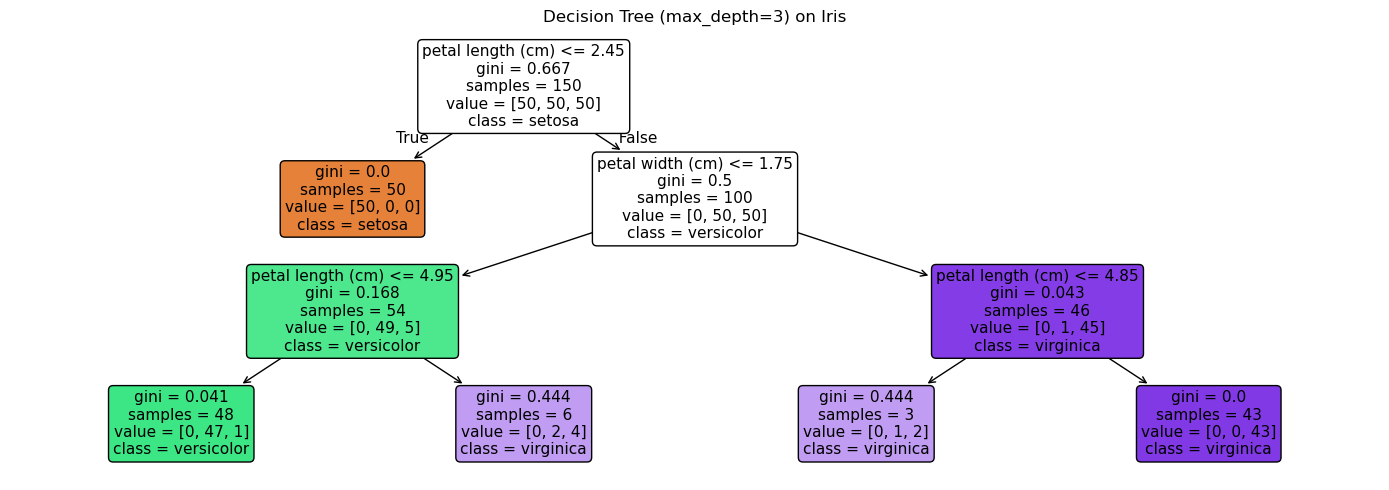

Train accuracy: 0.973
CV accuracy:    0.973


In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt.fit(X_iris, y_iris)

plt.figure(figsize=(14, 5))
plot_tree(dt, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True, rounded=True)
plt.title('Decision Tree (max_depth=3) on Iris')
plt.tight_layout()
plt.show()

print('Train accuracy:', round(dt.score(X_iris, y_iris), 3))
print('CV accuracy:   ', round(cross_val_score(dt, X_iris, y_iris, cv=5).mean(), 3))

## Q10b: Домішок Джині проти Ентропії — яка різниця і що обрати?

Обидва вимірюють **домішок вузла** — наскільки перемішані класи у розбивці. Чистий вузол (один клас) дає 0 для обох.

| | Формула | Діапазон | Швидкість |
|---|---|---|---|
| **Джині** | `1 - Σ pᵢ²` | [0, 0.5] для двох класів | Швидший (без логарифму) |
| **Ентропія** | `-Σ pᵢ log₂(pᵢ)` | [0, 1] для двох класів | Трохи повільніша |

**На практиці:** обидва майже завжди дають однакову структуру дерева і схожу точність. За замовчуванням використовуйте `gini` (швидше). Переходьте на `entropy`, якщо важлива інформаційна інтерпретація.

Розбивка обирається для **максимізації інформаційного приросту** = домішок(батьківський) − зважене середнє домішків(дочірні).


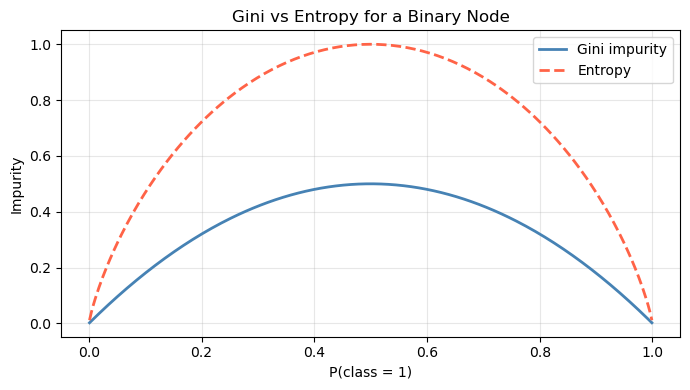

Parent gini:      0.5000
Left  gini:       0.2778  (6 samples: 5A, 1B)
Right gini:       0.0000  (4 samples: 0B, 4B = pure!)
Weighted child:   0.1667
Information Gain: 0.3333  ← the tree maximises this

CV accuracy comparison on Breast Cancer:
  criterion=gini   : 0.9191
  criterion=entropy: 0.9350
(difference is typically negligible)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# ── 1. Gini vs Entropy formula comparison ────────────────────────────────────
p = np.linspace(0.001, 0.999, 300)   # p = prob of class 1
gini    = 1 - (p**2 + (1-p)**2)
entropy = -(p * np.log2(p) + (1-p) * np.log2(1-p))

plt.figure(figsize=(7, 4))
plt.plot(p, gini,    label='Gini impurity', color='steelblue', linewidth=2)
plt.plot(p, entropy, label='Entropy',       color='tomato',    linewidth=2, linestyle='--')
plt.xlabel('P(class = 1)')
plt.ylabel('Impurity')
plt.title('Gini vs Entropy for a Binary Node')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. Information Gain example (manual) ─────────────────────────────────────
# Parent: 10 samples, 5 class-A, 5 class-B  → impurity = 0.5
# Split into Left (6 samples: 5A, 1B) and Right (4 samples: 0A, 4B)
def gini_node(pos, total):
    if total == 0: return 0
    p = pos / total
    return 1 - p**2 - (1-p)**2

parent_gini = gini_node(5, 10)
left_gini   = gini_node(5, 6)
right_gini  = gini_node(0, 4)
weighted    = (6/10) * left_gini + (4/10) * right_gini
info_gain   = parent_gini - weighted

print(f'Parent gini:      {parent_gini:.4f}')
print(f'Left  gini:       {left_gini:.4f}  (6 samples: 5A, 1B)')
print(f'Right gini:       {right_gini:.4f}  (4 samples: 0B, 4B = pure!)')
print(f'Weighted child:   {weighted:.4f}')
print(f'Information Gain: {info_gain:.4f}  ← the tree maximises this')

# ── 3. Accuracy comparison: gini vs entropy ───────────────────────────────────
print('\nCV accuracy comparison on Breast Cancer:')
for criterion in ['gini', 'entropy']:
    dt = DecisionTreeClassifier(max_depth=5, criterion=criterion, random_state=42)
    score = cross_val_score(dt, X_cancer, y_cancer, cv=5).mean()
    print(f'  criterion={criterion:7s}: {score:.4f}')
print('(difference is typically negligible)')

## Q11: Що таке Random Forest і чому він кращий за одне дерево рішень?

Random Forest навчає багато дерев рішень на **випадкових підвибірках** даних (бегінг) та випадкових підмножинах ознак. Передбачення робиться голосуванням більшістю серед усіх дерев.

**Чому краще:**
- Одне глибоке дерево перенавчається. Усереднення похибок багатьох дерев дає стабільніше передбачення.
- Випадковість ознак (`max_features`) забезпечує різноманітність дерев і некорельованість помилок.

**Ключові гіперпараметри:** `n_estimators` (більше = краще, але повільніше), `max_depth`, `max_features`


In [16]:
from sklearn.ensemble import RandomForestClassifier

single_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

dt_scores = cross_val_score(single_tree,  X_cancer, y_cancer, cv=5)
rf_scores  = cross_val_score(random_forest, X_cancer, y_cancer, cv=5)

print(f'Single Tree CV: {dt_scores.mean():.3f} ± {dt_scores.std():.3f}')
print(f'Random Forest CV: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}')
# RF should be higher accuracy AND lower std (more stable)

Single Tree CV: 0.917 ± 0.024
Random Forest CV: 0.956 ± 0.023


## Q12: Що таке Логістична регресія? (Попри назву — це класифікатор.)

Логістична регресія моделює **ймовірність** класу за допомогою сигмоїдної функції:

```
P(y=1 | x) = 1 / (1 + e^(-w·x))
```

Якщо P > 0.5 → клас 1, інакше клас 0. На відміну від дерева, межа рішення є прямою лінією (лінійна).

**Гіперпараметр `C`:** обернений до сили регуляризації. Малий C = більша регуляризація (простіша модель).


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scl', StandardScaler()),
    ('lr',  LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])

scores = cross_val_score(pipe, X_cancer, y_cancer, cv=5, scoring='accuracy')
print(f'Logistic Regression CV: {scores.mean():.3f} ± {scores.std():.3f}')

# Inspect learned coefficients (after fitting on full data)
pipe.fit(X_cancer, y_cancer)
coef = pipe.named_steps['lr'].coef_[0]
top5 = pd.Series(np.abs(coef), index=X_cancer.columns).nlargest(5)
print('\nTop 5 most influential features:')
print(top5.round(3))

Logistic Regression CV: 0.981 ± 0.007

Top 5 most influential features:
worst texture    1.321
radius error     1.289
worst radius     1.027
area error       0.999
worst area       0.995
dtype: float64


## Q13: Що таке Наївний Байєс?

Наївний Байєс застосовує теорему Байєса з «наївним» припущенням, що ознаки є **незалежними** за умови класу:

```
P(клас | ознаки) ∝ P(клас) × ∏ P(ознака_i | клас)
```

Це майже ніколи не виконується на реальних даних, але класифікатор працює напрочуд добре — особливо для класифікації тексту.

**Варіанти:**
- `GaussianNB` — числові ознаки мають нормальний розподіл
- `MultinomialNB` — частоти слів (текст)
- `BernoulliNB` — бінарні ознаки


In [18]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
scores = cross_val_score(nb, X_cancer, y_cancer, cv=5, scoring='accuracy')
print(f'GaussianNB CV: {scores.mean():.3f} ± {scores.std():.3f}')

# Bayes' theorem example (manual)
# P(disease | positive test) given:
p_disease  = 0.01   # prevalence
p_pos_given_disease = 0.99   # sensitivity
p_pos_given_no_disease = 0.05  # false positive rate

p_pos = p_pos_given_disease * p_disease + p_pos_given_no_disease * (1 - p_disease)
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_pos

print(f'\nBayes example: P(disease | positive test) = {p_disease_given_pos:.3f}')
print('Even with a 99% accurate test, only ~17% chance of disease when prevalence is 1%')

GaussianNB CV: 0.939 ± 0.015

Bayes example: P(disease | positive test) = 0.167
Even with a 99% accurate test, only ~17% chance of disease when prevalence is 1%


## Q14: Що таке метод опорних векторів (SVM)?

SVM знаходить **гіперплощину максимального зазору** — межу рішення, максимально віддалену від найближчих точок (опорних векторів) кожного класу.

**Ядровий трюк** відображає дані у простір вищої розмірності, дозволяючи нелінійні межі без явного обчислення перетворення.

**Ключові гіперпараметри:**
- `C` — компроміс між шириною зазору та помилками класифікації
- `kernel` — `'linear'`, `'rbf'` (найпоширеніший), `'poly'`
- `gamma` — радіус впливу кожної навчальної точки (для rbf)


In [19]:
from sklearn.svm import SVC

# SVM requires scaling
for kernel in ['linear', 'rbf']:
    pipe = Pipeline([
        ('scl', StandardScaler()),
        ('svm', SVC(kernel=kernel, C=1.0, random_state=42))
    ])
    score = cross_val_score(pipe, X_cancer, y_cancer, cv=5).mean()
    print(f'SVM ({kernel:6s}) CV accuracy: {score:.3f}')

SVM (linear) CV accuracy: 0.972


SVM (rbf   ) CV accuracy: 0.974


---
# 4. Алгоритми регресії

## Q15: Що таке лінійна регресія (МНК — метод найменших квадратів)?

МНК знаходить пряму (або гіперплощину), яка мінімізує суму квадратів залишків:

```
Втрати = Σ (y_i - ŷ_i)²
```

Аналітичний розв'язок:
```
w = (XᵀX)⁻¹ Xᵀy
```

Він точний — не потребує ітерацій (на відміну від градієнтного спуску). Однак стає повільним при дуже великій кількості ознак.


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('MAE: ', round(mean_absolute_error(y_test, y_pred), 2))
print('R²:  ', round(r2_score(y_test, y_pred), 3))

# OLS closed form (manual, 1-feature example)
X_simple = X_diab[['bmi']].values
X_b = np.hstack([np.ones((len(X_simple), 1)), X_simple])  # add bias column
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_diab.values
print(f'\nOLS (manual) — intercept: {w_ols[0]:.2f}, bmi coef: {w_ols[1]:.2f}')

MAE:  42.79
R²:   0.453

OLS (manual) — intercept: 152.13, bmi coef: 949.44


## Q16: Що таке градієнтний спуск?

Ітераційний алгоритм оптимізації. На кожному кроці переміщуємо ваги в напрямку, що найбільше зменшує функцію втрат (від'ємний градієнт):

```
w := w - α × ∇Втрати(w)
```

Де α — **швидкість навчання (learning rate)**:
- Занадто мала → повільна збіжність
- Занадто велика → перестрибування, можлива розбіжність

Використовується, коли матрична інверсія МНК занадто дорога (багато ознак) або коли немає аналітичного розв'язку (нейронні мережі).


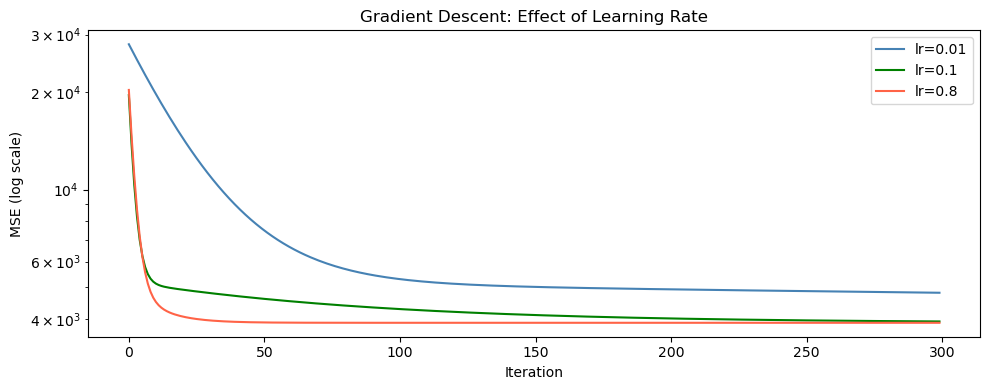

In [21]:
# Gradient descent for linear regression (from scratch)
X_raw = X_diab[['bmi']].values
X_norm = (X_raw - X_raw.min()) / (X_raw.max() - X_raw.min())  # normalise to [0,1]
X_b = np.hstack([np.ones((len(X_norm), 1)), X_norm])
y = y_diab.values

def mse(w, X, y):
    return np.mean((X @ w - y) ** 2)

plt.figure(figsize=(10, 4))

for lr_val, color in [(0.01, 'steelblue'), (0.1, 'green'), (0.8, 'tomato')]:
    w = np.zeros(2)
    losses = []
    for _ in range(300):
        grad = (2 / len(y)) * X_b.T @ (X_b @ w - y)
        w = w - lr_val * grad
        losses.append(mse(w, X_b, y))
    plt.plot(losses, label=f'lr={lr_val}', color=color)

plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('MSE (log scale)')
plt.title('Gradient Descent: Effect of Learning Rate')
plt.legend()
plt.tight_layout()
plt.show()

## Q17: Що таке регуляризація (Ridge / Lasso)?

Регуляризація додає штраф до функції втрат, щоб запобігти великим коефіцієнтам (перенавчанню):

| Метод | Штраф | Ефект |
|---|---|---|
| **Ridge (L2)** | `α × Σ w²` | Стискає всі ваги до нуля, зберігає всі ознаки |
| **Lasso (L1)** | `α × Σ \|w\|` | Деякі ваги обнуляються — **відбір ознак** |
| **ElasticNet** | суміш L1 + L2 | Поєднує обидва |

`alpha` контролює силу. Більший alpha → більша регуляризація → простіша модель.


In [22]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

for alpha in [0.01, 1.0, 10.0]:
    pipe_ridge = Pipeline([('scl', StandardScaler()), ('reg', Ridge(alpha=alpha))])
    pipe_lasso = Pipeline([('scl', StandardScaler()), ('reg', Lasso(alpha=alpha))])

    r_ridge = cross_val_score(pipe_ridge, X_diab, y_diab, cv=5, scoring='r2').mean()
    r_lasso = cross_val_score(pipe_lasso, X_diab, y_diab, cv=5, scoring='r2').mean()
    print(f'alpha={alpha:5.2f}  Ridge R²={r_ridge:.3f}  Lasso R²={r_lasso:.3f}')

# Lasso with enough alpha zeroes some coefficients entirely
lasso = Pipeline([('scl', StandardScaler()), ('reg', Lasso(alpha=1.0))])
lasso.fit(X_diab, y_diab)
coef = pd.Series(lasso.named_steps['reg'].coef_, index=X_diab.columns)
print('\nLasso coefficients (0 = feature dropped):')
print(coef.round(2))

alpha= 0.01  Ridge R²=0.482  Lasso R²=0.482
alpha= 1.00  Ridge R²=0.482  Lasso R²=0.482
alpha=10.00  Ridge R²=0.481  Lasso R²=0.439

Lasso coefficients (0 = feature dropped):
age    -0.00
sex    -9.32
bmi    24.83
bp     14.09
s1     -4.84
s2     -0.00
s3    -10.62
s4      0.00
s5     24.42
s6      2.56
dtype: float64


## Q17b: Чим Ridge і Lasso справді відрізняються — геометрія та інтерпретація?

**Ridge (L2)** обмежує ваги сферою: всі коефіцієнти рівномірно стискаються до нуля, але жоден не досягає його точно. Добре, коли **всі ознаки дещо важливі**.

**Lasso (L1)** обмежує ваги ромбом: кути ромба лежать на осях, тому оптимум часто потрапляє точно в кут — тобто **деякі коефіцієнти стають рівно нулю** (автоматичний відбір ознак). Добре, коли підозрюєте, що багато ознак нерелевантні.

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Штраф | $\\alpha \\sum w_i^2$ | $\\alpha \\sum \|w_i\|$ |
| Обнуляє ваги? | Ні | Так |
| Використовувати коли | Всі ознаки релевантні | Багато нерелевантних ознак |

**`alpha`:** більше → сильніша регуляризація → простіша модель. Обирайте через `RidgeCV`/`LassoCV` або `GridSearchCV`.


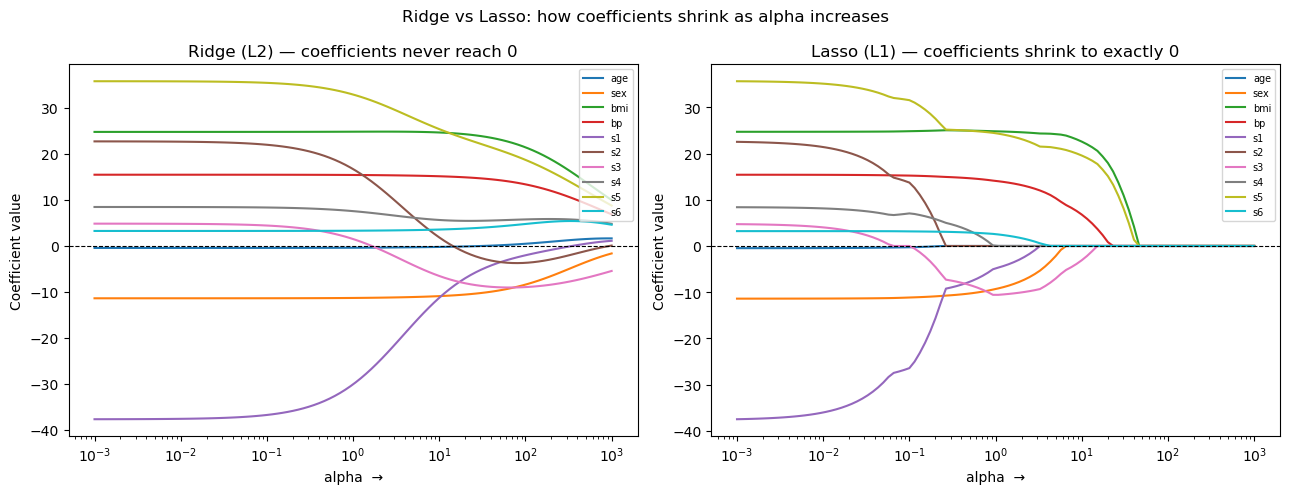

Lasso (alpha=0.5): 8 kept, 2 zeroed
Kept:   ['sex', 'bmi', 'bp', 's1', 's3', 's4', 's5', 's6']
Zeroed: ['age', 's2']


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes

X_d, y_d = load_diabetes(as_frame=True, return_X_y=True)
feature_names = X_d.columns.tolist()
X_sc = StandardScaler().fit_transform(X_d)

alphas = np.logspace(-3, 3, 100)
ridge_coefs = np.array([Ridge(alpha=a).fit(X_sc, y_d).coef_ for a in alphas])
lasso_coefs = np.array([Lasso(alpha=a, max_iter=5000).fit(X_sc, y_d).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, coefs, title in [
        (axes[0], ridge_coefs, 'Ridge (L2) — coefficients never reach 0'),
        (axes[1], lasso_coefs, 'Lasso (L1) — coefficients shrink to exactly 0')]:
    for j, name in enumerate(feature_names):
        ax.plot(alphas, coefs[:, j], label=name)
    ax.set_xscale('log')
    ax.set_xlabel('alpha  →')
    ax.set_ylabel('Coefficient value')
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=7, loc='upper right')
plt.suptitle('Ridge vs Lasso: how coefficients shrink as alpha increases')
plt.tight_layout()
plt.show()

# Which features does Lasso zero out?
lasso_fit = Lasso(alpha=0.5, max_iter=5000).fit(X_sc, y_d)
kept = [(n, c) for n, c in zip(feature_names, lasso_fit.coef_) if c != 0]
zeroed = [(n, c) for n, c in zip(feature_names, lasso_fit.coef_) if c == 0]
print(f'Lasso (alpha=0.5): {len(kept)} kept, {len(zeroed)} zeroed')
print('Kept:  ', [n for n, _ in kept])
print('Zeroed:', [n for n, _ in zeroed])

---
# 5. Оцінка моделей — Класифікація

## Q18: Що таке матриця плутанини (Confusion Matrix)?

Матриця плутанини показує **кількість** правильних і неправильних передбачень у розрізі класів:

```
                 Передбачено
              Neg    Pos
Факт  Neg  [ TN    FP ]
      Pos  [ FN    TP ]
```

- **TP** Справжній позитив: правильно передбачений позитив
- **TN** Справжній негатив: правильно передбачений негатив
- **FP** Хибний позитив (Помилка I роду): передбачено позитив, фактично негатив
- **FN** Хибний негатив (Помилка II роду): передбачено негатив, фактично позитив


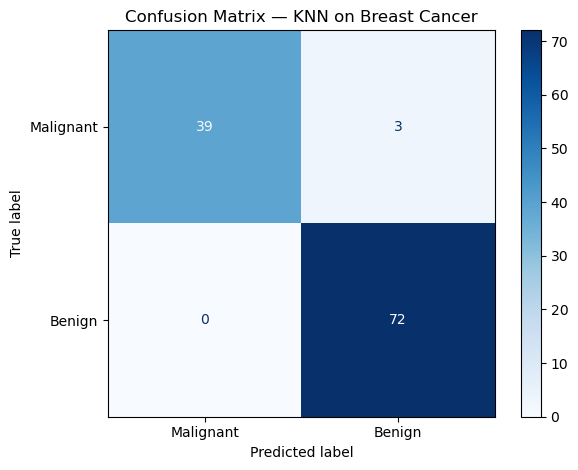

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

pipe = Pipeline([('scl', StandardScaler()),
                 ('knn', KNeighborsClassifier(n_neighbors=7))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — KNN on Breast Cancer')
plt.tight_layout()
plt.show()

## Q19: Що таке Accuracy, Precision, Recall та F1?

| Метрика | Формула | Відповідає на питання |
|---|---|---|
| **Accuracy** | (TP+TN) / всього | Яка частка передбачень правильна? |
| **Precision** | TP / (TP+FP) | З усього, що я назвав позитивом, скільки справді є? |
| **Recall** | TP / (TP+FN) | З усіх реальних позитивів, скільки я впіймав? |
| **F1** | 2 × P×R / (P+R) | Гармонійне середнє між Precision та Recall |

**Коли Accuracy вводить в оману:** якщо 95% листів не є спамом, модель, яка завжди передбачає «не спам», отримає 95% — але не впіймає жодного спаму. Precision/Recall показують реальну картину.


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1 score:  {f1_score(y_test, y_pred):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Accuracy:  0.974
Precision: 0.960
Recall:    1.000


F1 score:  0.980

              precision    recall  f1-score   support

   Malignant       1.00      0.93      0.96        42
      Benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## Q20: Що таке ROC-AUC і як його інтерпретувати?

**ROC-крива** будує графік Частки справжніх позитивів (Recall) проти Частки хибних позитивів при кожному порозі класифікації (0 → 1).

**AUC (площа під кривою):**
- 1.0 = ідеальний класифікатор
- 0.5 = випадкове вгадування (діагональна пряма)
- < 0.5 = гірше за випадкове

AUC **не залежить від порогу** — він показує, наскільки добре модель ранжує позитиви вище негативів, незалежно від вибраного порогу. Корисний при дисбалансі класів.


ROC-AUC: 0.988


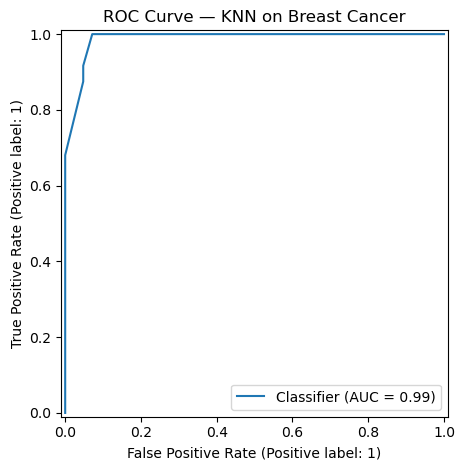

In [26]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Need predict_proba for ROC
pipe_proba = Pipeline([('scl', StandardScaler()),
                       ('knn', KNeighborsClassifier(n_neighbors=7))])
pipe_proba.fit(X_train, y_train)
y_proba = pipe_proba.predict_proba(X_test)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve — KNN on Breast Cancer')
plt.tight_layout()
plt.show()

## Q20b: Яку метрику класифікації коли використовувати — і як інтерпретувати?

| Метрика | Використовувати коли | Що ігнорувати не можна |
|---|---|---|
| **Accuracy** | Класи збалансовані | Вводить в оману при дисбалансі |
| **Precision** | Хибні позитиви дорогі (спам-фільтр, надмірні сповіщення) | Модель з високим Recall мітить усе |
| **Recall** | Хибні негативи дорогі (рак, шахрайство) | Модель з високим Precision пропускає справжні випадки |
| **F1** | Потрібен баланс між P і R | Приховує, *який* тип помилки гірший |
| **ROC-AUC** | Порівняння моделей незалежно від порогу | Не вказує операційну точку |

**Як читати значення:**
- Accuracy `0.95` на наборі 95/5: модель, що завжди передбачає більший клас, теж отримає 0.95. Марно.
- Precision `0.80`: 80% ваших позитивних передбачень справді позитивні.
- Recall `0.60`: ви впіймали 60% усіх реальних позитивів — 40% пропустили.
- F1 `0.70`: збалансована оцінка.
- AUC `0.97`: модель ранжує випадковий позитив вище випадкового негативу у 97% випадків.

**Практичне правило:** медицина → максимізуйте Recall (не пропускайте). Спам-фільтр → максимізуйте Precision.


Balanced vs imbalanced — why accuracy lies:



  Balanced (50/50)
    Naive baseline accuracy: 0.500
    Model accuracy:          0.885
    Model precision:         0.889
    Model recall:            0.880
    Model F1:                0.884
    Model ROC-AUC:           0.934

  Imbalanced (95/5)
    Naive baseline accuracy: 0.945
    Model accuracy:          0.945
    Model precision:         0.500
    Model recall:            0.182
    Model F1:                0.267
    Model ROC-AUC:           0.886


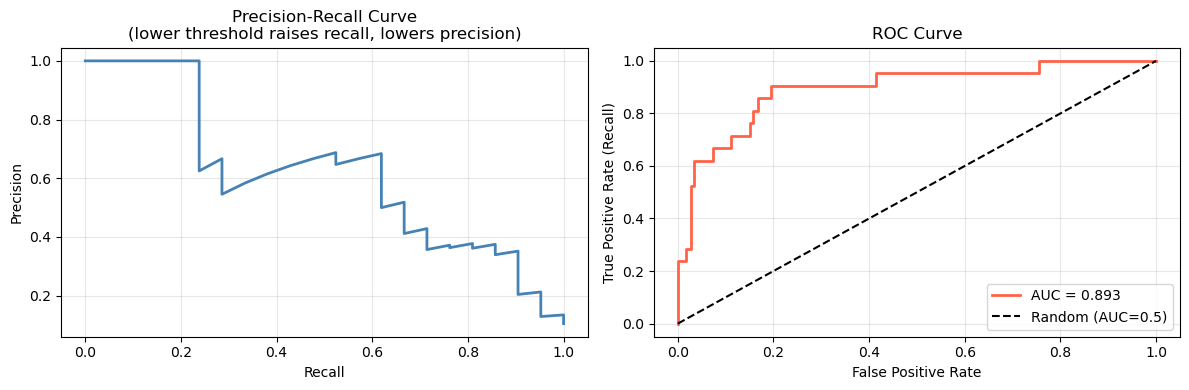

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score,
                              precision_recall_curve, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print('Balanced vs imbalanced — why accuracy lies:')
for ratio, label in [((0.5, 0.5), 'Balanced (50/50)'),
                      ((0.95, 0.05), 'Imbalanced (95/5)')]:
    X, y = make_classification(n_samples=1000, weights=list(ratio), random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                               stratify=y, random_state=42)
    pipe = Pipeline([('scl', StandardScaler()),
                     ('lr', LogisticRegression(max_iter=500))])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]
    naive = np.zeros_like(y_te)  # always predict majority
    print(f'\n  {label}')
    print(f'    Naive baseline accuracy: {accuracy_score(y_te, naive):.3f}')
    print(f'    Model accuracy:          {accuracy_score(y_te, y_pred):.3f}')
    print(f'    Model precision:         {precision_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'    Model recall:            {recall_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'    Model F1:                {f1_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'    Model ROC-AUC:           {roc_auc_score(y_te, y_proba):.3f}')

# Precision-Recall trade-off at different thresholds
X, y = make_classification(n_samples=1000, weights=[0.9, 0.1], random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
pipe = Pipeline([('scl', StandardScaler()), ('lr', LogisticRegression(max_iter=500))])
pipe.fit(X_tr, y_tr)
proba = pipe.predict_proba(X_te)[:, 1]
prec, rec, _ = precision_recall_curve(y_te, proba)
fpr, tpr, _  = roc_curve(y_te, proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rec, prec, color='steelblue', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve\n(lower threshold raises recall, lowers precision)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(fpr, tpr, color='tomato', linewidth=2,
             label=f'AUC = {roc_auc_score(y_te, proba):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 6. Оцінка моделей — Регресія

## Q21: Що таке MAE, MSE та RMSE?

| Метрика | Формула | Властивості |
|---|---|---|
| **MAE** | mean(\|y - ŷ\|) | Ті ж одиниці, що й ціль; стійка до викидів |
| **MSE** | mean((y - ŷ)²) | Сильно штрафує великі помилки; не в оригінальних одиницях |
| **RMSE** | √MSE | Ті ж одиниці; теж штрафує великі помилки |

Обирайте **MAE**, якщо викиди не мають надмірно штрафуватися (наприклад, ціни будинків). Обирайте **RMSE**, якщо великі помилки особливо небажані.


MAE:  44.05
MSE:  2952.01
RMSE: 54.33
R²:   0.443


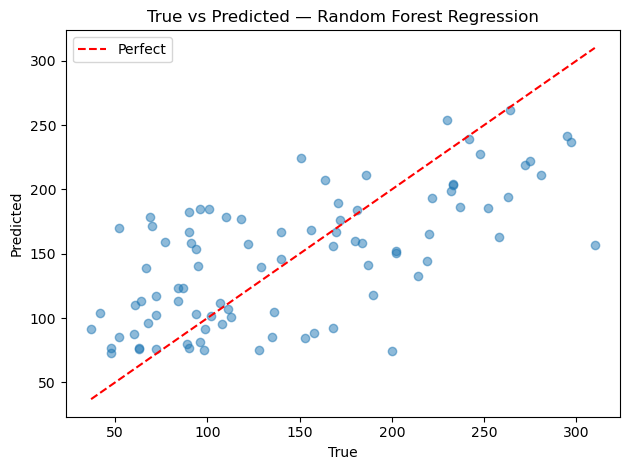

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

X_tr, X_te, y_tr, y_te = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)
y_hat = rf.predict(X_te)

mae  = mean_absolute_error(y_te, y_hat)
mse  = mean_squared_error(y_te, y_hat)
rmse = np.sqrt(mse)
r2   = r2_score(y_te, y_hat)

print(f'MAE:  {mae:.2f}')
print(f'MSE:  {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²:   {r2:.3f}')

plt.scatter(y_te, y_hat, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', label='Perfect')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('True vs Predicted — Random Forest Regression')
plt.legend()
plt.tight_layout()
plt.show()

## Q22: Що таке R² (коефіцієнт детермінації)?

R² вимірює, яку частку дисперсії цільової змінної пояснює модель:

```
R² = 1 - (SS_res / SS_tot)
   = 1 - Σ(y-ŷ)² / Σ(y-mean(y))²
```

- R² = 1.0 → ідеальні передбачення
- R² = 0.0 → модель не краща за передбачення середнього
- R² < 0  → модель гірша за передбачення середнього

На відміну від RMSE, R² **не залежить від масштабу**, що полегшує порівняння між різними наборами даних.


In [29]:
y_true = np.array([3, -0.5, 2, 7])
y_pred_good  = np.array([2.5,  0.0, 2, 8])
y_pred_mean  = np.full_like(y_true, y_true.mean(), dtype=float)  # always predict mean
y_pred_bad   = np.array([10,  10,  10, 10])  # terrible model

for label, yp in [('Good model', y_pred_good),
                   ('Mean baseline', y_pred_mean),
                   ('Bad model', y_pred_bad)]:
    print(f'{label:15s}  R² = {r2_score(y_true, yp):.3f}')

Good model       R² = 0.949
Mean baseline    R² = 0.000
Bad model        R² = -6.957


## Q22b: Як обирати і інтерпретувати метрики регресії?

| Метрика | Ті ж одиниці? | Штрафує викиди? | Використовувати коли |
|---|---|---|---|
| **MAE** | Так | Ні (лінійно) | Є викиди; потрібна інтерпретованість |
| **MSE** | Ні (квадрат) | Так (квадратично) | Рідко звітують; використовують у функціях втрат |
| **RMSE** | Так | Так (квадратично) | Великі помилки особливо небажані |
| **R²** | Ні (0–1) | — | Незалежне від масштабу порівняння |

**Як інтерпретувати:**
- MAE = 42 для цін будинків (у тис. грн) → середнє відхилення передбачення — 42 тис. грн.
- RMSE = 65 >> MAE = 42 → кілька передбачень дуже далекі від реальності (викиди залишків).
- R² = 0.85 → модель пояснює 85% дисперсії.
- R² = 0.0 → не краще за просте передбачення середнього.
- R² < 0 → модель *гірша* за базовий рівень середнього.

**Графік залишків:** передбачені значення проти (реальні − передбачені). Має бути горизонтальна смуга навколо 0. Паттерни (лійка, крива) вказують на проблеми.


  Model                MAE     RMSE       R2  Gap(RMSE-MAE)
------------------------------------------------------------
  Good model          4.02     5.09    0.916  1.06
  Outlier model       9.03    32.18   -2.345  23.15
  Mean baseline      14.19    17.59    0.000  3.40

Large RMSE-MAE gap = a few big mistakes. Mean baseline R2 = 0 by definition.


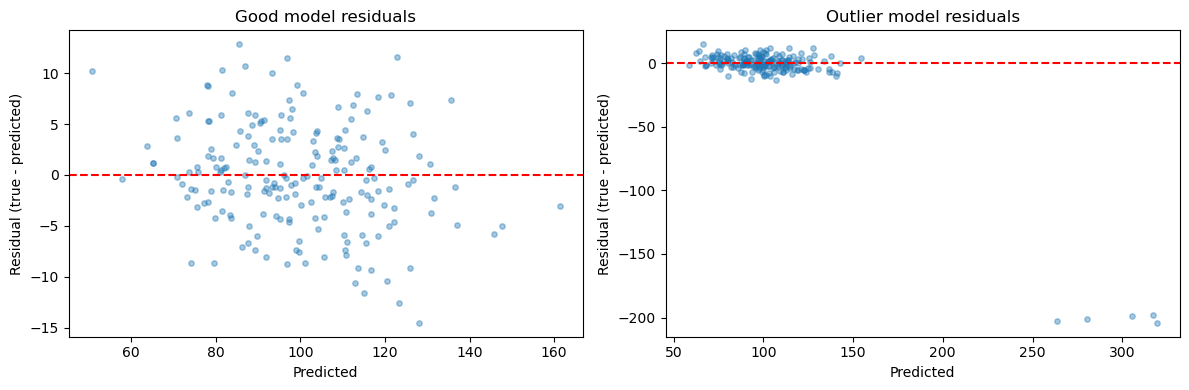

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rng = np.random.default_rng(42)
y_true = rng.normal(100, 20, 200)
y_good    = y_true + rng.normal(0, 5, 200)
y_outlier = y_true + rng.normal(0, 5, 200)
y_outlier[:5] += 200  # 5 catastrophic errors
y_mean_pred = np.full_like(y_true, y_true.mean())

print(f'  {"Model":15s}  {"MAE":>7}  {"RMSE":>7}  {"R2":>7}  Gap(RMSE-MAE)')
print('-' * 60)
for name, yp in [('Good model', y_good),
                  ('Outlier model', y_outlier),
                  ('Mean baseline', y_mean_pred)]:
    mae  = mean_absolute_error(y_true, yp)
    rmse = np.sqrt(mean_squared_error(y_true, yp))
    r2   = r2_score(y_true, yp)
    print(f'  {name:15s}  {mae:7.2f}  {rmse:7.2f}  {r2:7.3f}  {rmse-mae:.2f}')
print()
print('Large RMSE-MAE gap = a few big mistakes. Mean baseline R2 = 0 by definition.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yp, title in [(axes[0], y_good, 'Good model residuals'),
                       (axes[1], y_outlier, 'Outlier model residuals')]:
    residuals = y_true - yp
    ax.scatter(yp, residuals, alpha=0.4, s=15)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (true - predicted)')
    ax.set_title(title)
plt.tight_layout()
plt.show()

---
# 7. Налаштування гіперпараметрів та перенавчання

## Q23: Яка різниця між параметрами та гіперпараметрами?

| | Параметри | Гіперпараметри |
|---|---|---|
| **Що** | Значення, які модель вивчає з даних | Значення, які ви задаєте до навчання |
| **Приклади** | Пороги розбивки дерева, ваги лінійної регресії | `max_depth`, `n_neighbors`, `C`, `alpha` |
| **Як задаються** | Автоматично під час `.fit()` | Вручну або через Grid Search |

Гіперпараметри контролюють складність моделі та поведінку навчання. Невдалий вибір призводить до недонавчання або перенавчання.


In [31]:
# After training, we can inspect the learned parameters
lr = LinearRegression()
lr.fit(X_diab, y_diab)

print('Learned parameters (coefficients):')
for feat, coef in zip(X_diab.columns, lr.coef_):
    print(f'  {feat:4s}: {coef:8.2f}')
print(f'  bias (intercept): {lr.intercept_:.2f}')
print()
print('Hyperparameters (you control these, not learned):')
print(' ', lr.get_params())

Learned parameters (coefficients):
  age :   -10.01
  sex :  -239.82
  bmi :   519.85
  bp  :   324.38
  s1  :  -792.18
  s2  :   476.74
  s3  :   101.04
  s4  :   177.06
  s5  :   751.27
  s6  :    67.63
  bias (intercept): 152.13

Hyperparameters (you control these, not learned):
  {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


## Q24: Що таке перенавчання та недонавчання?

```
                      Складність моделі →
Похибка
  │\                              /
  │  \   Недонавчання            / Перенавчання
  │    \_________________________/
  │              Оптимум
  └──────────────────────────────────
```

- **Недонавчання (висока систематична помилка):** модель занадто проста → погано на навчальній та тестовій вибірках
- **Перенавчання (висока дисперсія):** модель занадто складна → добре на навчальній, погано на тестовій
- **Сигнали:** великий розрив між навчальною та CV/тестовою точністю = перенавчання


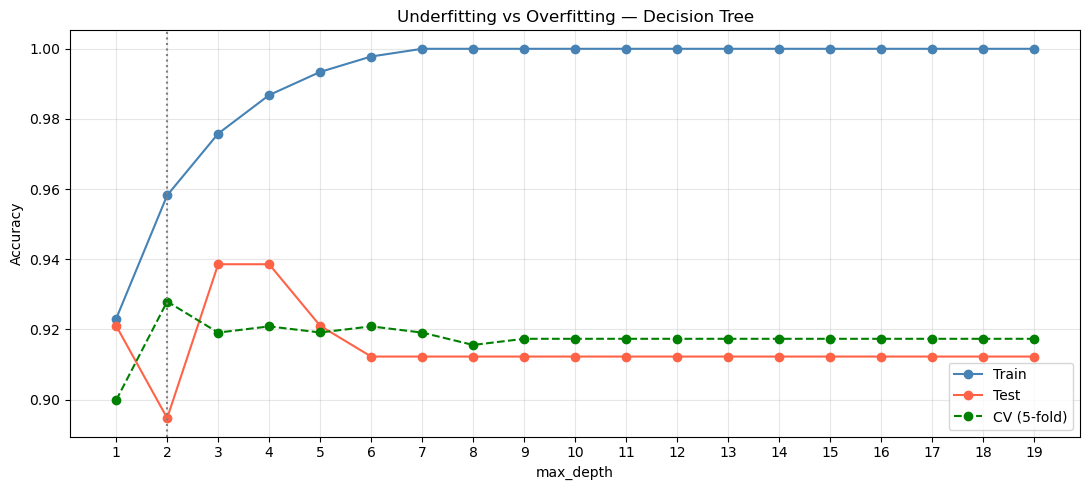

Best depth by CV: 2


In [32]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

depths = range(1, 20)
train_acc, test_acc, cv_acc = [], [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, dt.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, dt.predict(X_te)))
    cv_acc.append(cross_val_score(dt, X_cancer, y_cancer, cv=5).mean())

best_d = list(depths)[np.argmax(cv_acc)]

plt.figure(figsize=(11, 5))
plt.plot(depths, train_acc, marker='o', label='Train', color='steelblue')
plt.plot(depths, test_acc,  marker='o', label='Test',  color='tomato')
plt.plot(depths, cv_acc,    marker='o', label='CV (5-fold)', color='green', linestyle='--')
plt.axvline(best_d, color='gray', linestyle=':', linewidth=1.5)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Underfitting vs Overfitting — Decision Tree')
plt.legend()
plt.xticks(list(depths))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Best depth by CV: {best_d}')

## Q25: Що таке GridSearchCV і як він працює?

GridSearchCV перебирає всі комбінації гіперпараметрів із сітки та оцінює кожну за допомогою крос-валідації. Повертає комбінацію з найкращим CV-показником.

**Іменування всередині Pipeline:** використовуйте `назва_кроку__параметр` — наприклад, `'model__max_depth'`.

**Увага:** при великій сітці кількість навчань = `|комбінацій| × кількість_фолдів`. 100 комбінацій × 5 фолдів = 500 навчань моделі. Використовуйте `n_jobs=-1` для паралелізму.


In [33]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scl',   StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_grid = {
    'model__n_neighbors': [3, 5, 7, 11, 15, 21],
    'model__weights':     ['uniform', 'distance']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_cancer, y_cancer)

print('Best params: ', grid.best_params_)
print('Best CV score:', round(grid.best_score_, 4))

Best params:  {'model__n_neighbors': 7, 'model__weights': 'uniform'}
Best CV score: 0.9701


## Q26: Що таке RandomizedSearchCV і коли його використовувати замість GridSearchCV?

GridSearchCV перебирає **всі комбінації**. При великих сітках це дорого. RandomizedSearchCV вибирає **випадкову підмножину** комбінацій — кількість контролюється через `n_iter`.

**Практичне правило:** використовуйте `GridSearchCV` для малих сіток (< ~100 комбінацій); `RandomizedSearchCV` для великих сіток або коли параметри охоплюють широкі неперервні діапазони.


In [34]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

pipe = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

param_dist = {
    'model__n_estimators':      randint(50, 300),
    'model__max_depth':         [None, 3, 5, 7, 10],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf':  randint(1, 10)
}

rand_search = RandomizedSearchCV(
    pipe, param_dist, n_iter=20, cv=5,
    scoring='accuracy', random_state=42, n_jobs=-1
)
rand_search.fit(X_cancer, y_cancer)

print('Best params: ', rand_search.best_params_)
print('Best CV score:', round(rand_search.best_score_, 4))

Best params:  {'model__max_depth': 7, 'model__min_samples_leaf': 2, 'model__min_samples_split': 7, 'model__n_estimators': 103}
Best CV score: 0.9596


---
# 8. Теорія ймовірностей і статистика

## Q27: Що таке ФМЙ, ФЩЙ та ФРЙ?

| | ФМЙ (PMF) | ФЩЙ (PDF) | ФРЙ (CDF) |
|---|---|---|---|
| **Для** | Дискретні змінні | Неперервні змінні | Обох |
| **Дає** | P(X = x) | Щільність у точці x (не ймовірність) | P(X ≤ x) |
| **Сума/інтеграл** | 1 (сума) | 1 (інтеграл) | Досягає 1 праворуч |

Приклад: кидання кубика → ФМЙ. Ріст людини → ФЩЙ.


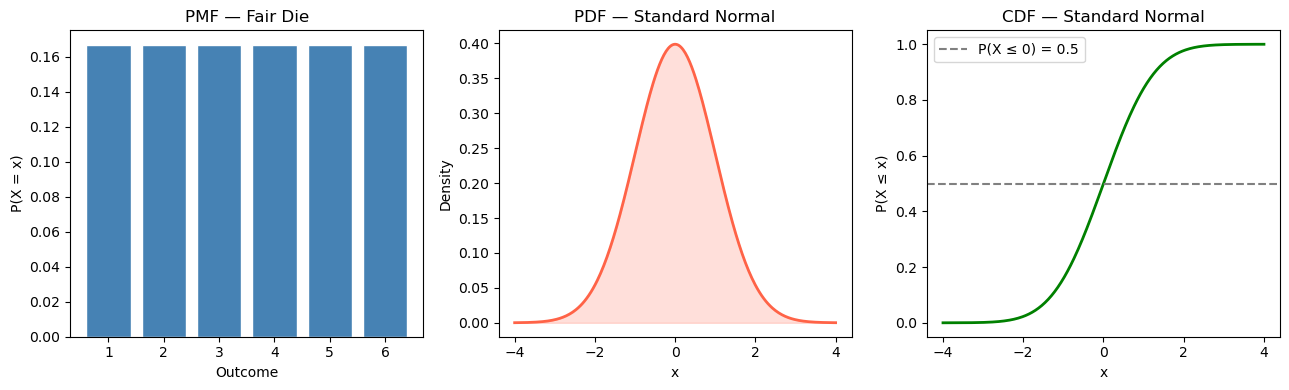

In [35]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# PMF — fair die
faces = np.arange(1, 7)
axes[0].bar(faces, [1/6]*6, color='steelblue', edgecolor='white')
axes[0].set_title('PMF — Fair Die')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('P(X = x)')

# PDF — standard normal
x = np.linspace(-4, 4, 300)
axes[1].plot(x, norm.pdf(x), color='tomato', linewidth=2)
axes[1].fill_between(x, norm.pdf(x), alpha=0.2, color='tomato')
axes[1].set_title('PDF — Standard Normal')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')

# CDF — standard normal
axes[2].plot(x, norm.cdf(x), color='green', linewidth=2)
axes[2].axhline(0.5, color='gray', linestyle='--', label='P(X ≤ 0) = 0.5')
axes[2].set_title('CDF — Standard Normal')
axes[2].set_xlabel('x')
axes[2].set_ylabel('P(X ≤ x)')
axes[2].legend()

plt.tight_layout()
plt.show()

## Q28: Що таке теорема Байєса?

Теорема Байєса оновлює ймовірність гіпотези з урахуванням нових свідчень:

```
P(H | E) = P(E | H) × P(H) / P(E)
```

- **P(H)** — апріорна ймовірність: що ви думали до отримання свідчень
- **P(E|H)** — правдоподібність: ймовірність свідчень, якщо гіпотеза вірна
- **P(H|E)** — апостеріорна: оновлене переконання після отримання свідчень

Це основа класифікаторів Наївного Байєса та імовірнісного МН.


In [36]:
# Medical test example
scenarios = [
    ('Rare disease (1%)',    0.01),
    ('Common disease (10%)', 0.10),
    ('Very common (40%)',    0.40),
]

sensitivity = 0.99   # P(test+ | disease)
fpr         = 0.05   # P(test+ | no disease)

print(f'Test sensitivity: {sensitivity*100:.0f}%  False positive rate: {fpr*100:.0f}%')
print('-' * 55)

for label, prevalence in scenarios:
    p_positive = sensitivity * prevalence + fpr * (1 - prevalence)
    posterior  = (sensitivity * prevalence) / p_positive
    print(f'{label:25s} → P(disease | positive) = {posterior:.2%}')

Test sensitivity: 99%  False positive rate: 5%
-------------------------------------------------------
Rare disease (1%)         → P(disease | positive) = 16.67%
Common disease (10%)      → P(disease | positive) = 68.75%
Very common (40%)         → P(disease | positive) = 92.96%


## Q29: Що таке оцінка максимальної правдоподібності (MLE)?

MLE знаходить значення параметрів, які роблять спостережувані дані найбільш ймовірними:

```
θ_MLE = argmax_θ  P(дані | θ)
```

На практиці максимізуємо **логарифм правдоподібності** (легше обчислити, той самий результат).

Приклад: оцінка середнього та стандартного відхилення Гауссіана за даними. MLE дає `μ = вибіркове_середнє`, `σ = вибіркове_std`.


In [37]:
from scipy.stats import norm
from scipy.optimize import minimize

# Generate data from N(5, 2)
np.random.seed(42)
data = np.random.normal(loc=5, scale=2, size=200)

def neg_log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    return -np.sum(norm.logpdf(data, loc=mu, scale=sigma))

result = minimize(neg_log_likelihood, x0=[0, 1], args=(data,),
                  bounds=[(None, None), (1e-6, None)])  # sigma must be > 0
mu_mle, sigma_mle = result.x

print(f'True    μ=5, σ=2')
print(f'MLE     μ={mu_mle:.3f}, σ={sigma_mle:.3f}')
print(f'Sample  μ={data.mean():.3f}, σ={data.std():.3f}')
# MLE = sample mean / sample std for Gaussian

True    μ=5, σ=2
MLE     μ=4.918, σ=1.857
Sample  μ=4.918, σ=1.857


## Q29b: Що таке дисперсія та стандартне відхилення?

**Дисперсія** вимірює розкид значень навколо середнього:

```
Var(X) = E[(X − μ)²] = (1/n) Σ (xᵢ − μ)²   ← генеральна
                       (1/(n-1)) Σ (xᵢ − μ)²  ← вибіркова (поправка Бесселя)
```

**Стандартне відхилення** = √Var(X) — ті ж одиниці, що й вихідна змінна.

| Поняття | Формула | Зміст |
|---|---|---|
| Дисперсія σ² | E[(X−μ)²] | Середнє квадратичне відхилення від середнього |
| Стд. відхилення σ | √σ² | Типова відстань від середнього |
| Коефіцієнт варіації | σ/μ | Відносний розкид (без одиниць виміру) |

**У МН:** ознаки з більшою дисперсією несуть більше інформації, але можуть потребувати масштабування. PCA знаходить напрямки максимальної дисперсії.


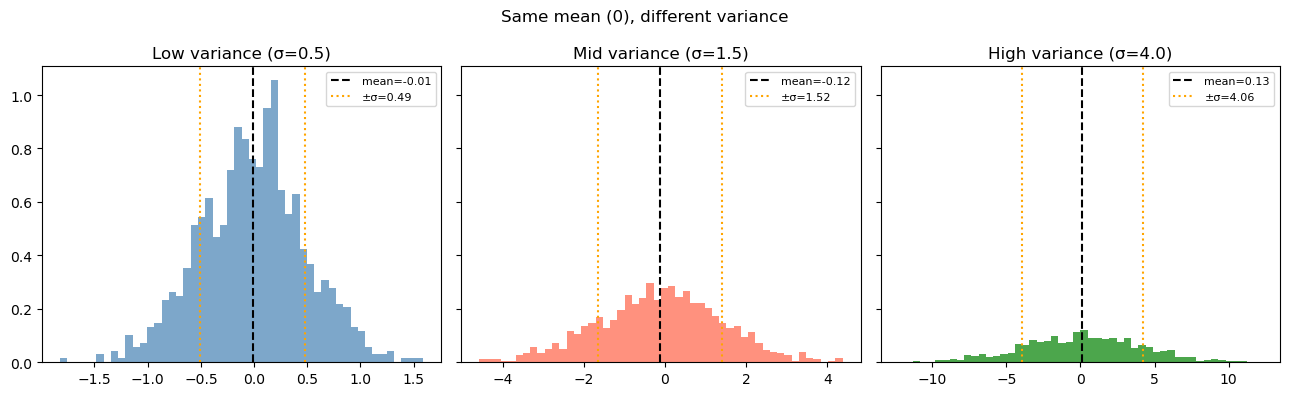

Data: [2. 4. 4. 4. 5. 5. 7. 9.]
Mean:              5.0000
Population var:    4.0000    (divides by n=8)
Sample var:        4.5714  (divides by n-1=7, Bessel correction)
Population std:    2.0000
Sample std:        2.1381
Coeff of variation:0.4000  (relative spread)


In [38]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Three distributions with same mean, different variance
low_var  = rng.normal(0, 0.5, 1000)
mid_var  = rng.normal(0, 1.5, 1000)
high_var = rng.normal(0, 4.0, 1000)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, data, color, label in zip(
        axes,
        [low_var, mid_var, high_var],
        ['steelblue', 'tomato', 'green'],
        ['Low variance (σ=0.5)', 'Mid variance (σ=1.5)', 'High variance (σ=4.0)']):
    ax.hist(data, bins=50, color=color, alpha=0.7, density=True)
    ax.axvline(data.mean(), color='black', linestyle='--', label=f'mean={data.mean():.2f}')
    ax.axvline(data.mean() + data.std(), color='orange', linestyle=':', label=f'±σ={data.std():.2f}')
    ax.axvline(data.mean() - data.std(), color='orange', linestyle=':')
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.suptitle('Same mean (0), different variance')
plt.tight_layout()
plt.show()

# Population vs sample variance
x = np.array([2., 4., 4., 4., 5., 5., 7., 9.])
print(f'Data: {x}')
print(f'Mean:              {x.mean():.4f}')
print(f'Population var:    {x.var():.4f}    (divides by n={len(x)})')
print(f'Sample var:        {x.var(ddof=1):.4f}  (divides by n-1={len(x)-1}, Bessel correction)')
print(f'Population std:    {x.std():.4f}')
print(f'Sample std:        {x.std(ddof=1):.4f}')
print(f'Coeff of variation:{x.std()/x.mean():.4f}  (relative spread)')


## Q29c: Що таке центральна гранична теорема (ЦГТ)?

**Твердження:** якщо брати n незалежних вибірок з *будь-якого* розподілу з кінцевим середнім μ та дисперсією σ², розподіл **вибіркового середнього** наближається до нормального при n → ∞:

```
x̄ ~ N(μ,  σ²/n)
```

**Що це означає на практиці:**
- Незалежно від форми розподілу даних, середні великих вибірок є приблизно нормальними.
- Саме тому можна використовувати t-тести, довірчі інтервали та p-значення без припущення нормальності сирих даних.
- Показники крос-валідації є приблизно нормальними — це виправдовує звітність у форматі mean ± std.
- Стандартна помилка середнього (SEM) = σ / √n — більші вибірки дають точніші оцінки.


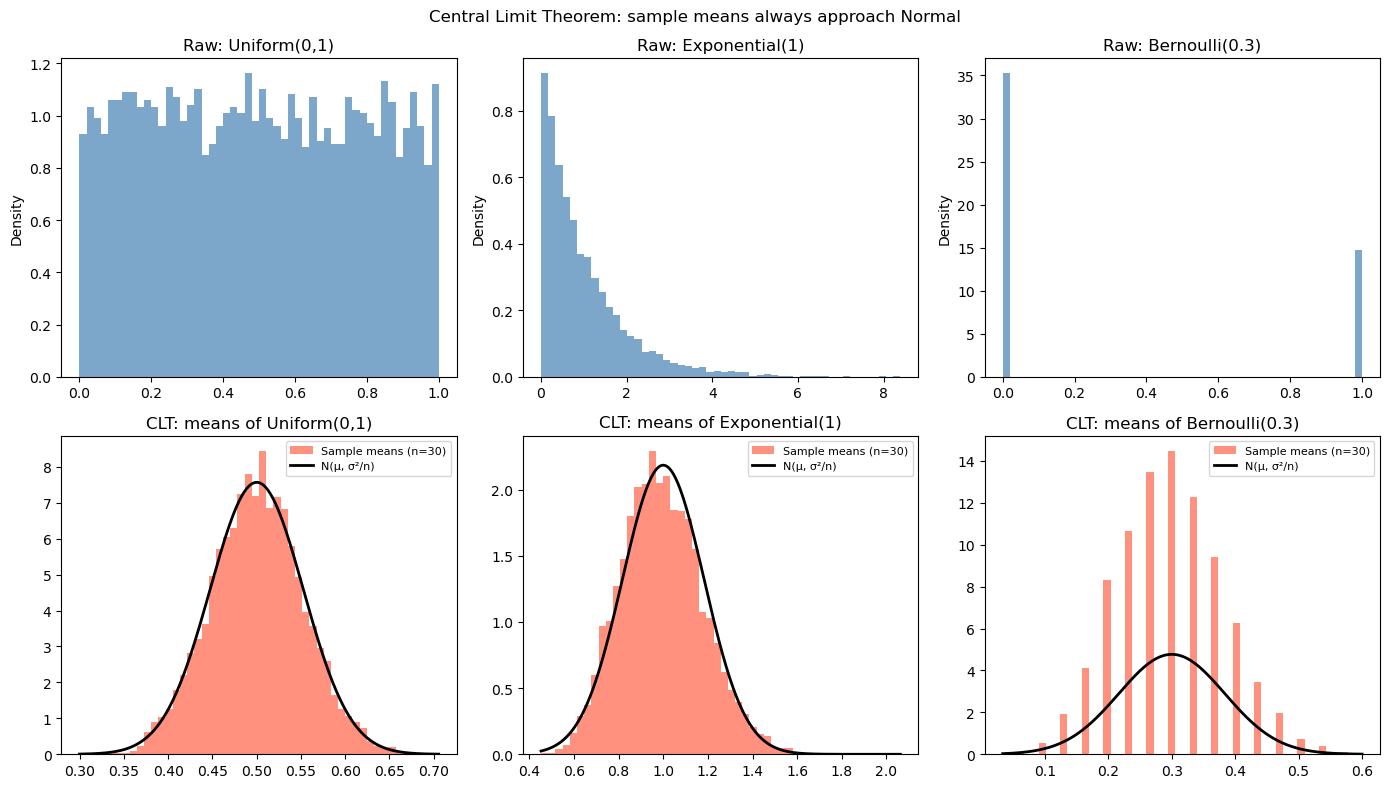

Standard Error of Mean (SEM = σ/√n) for N(0,1):
  n=    5: SEM = 0.4472
  n=   10: SEM = 0.3162
  n=   30: SEM = 0.1826
  n=  100: SEM = 0.1000
  n= 1000: SEM = 0.0316


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(42)
n_experiments = 5000

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

distributions = [
    ('Uniform(0,1)',   lambda n: rng.uniform(0, 1, n),        0.5,    1/12),
    ('Exponential(1)', lambda n: rng.exponential(1, n),        1.0,    1.0 ),
    ('Bernoulli(0.3)', lambda n: rng.binomial(1, 0.3, n),      0.3,    0.21),
]

for col, (name, sampler, mu, var) in enumerate(distributions):
    # Raw distribution (n=1)
    raw = sampler(n_experiments)
    axes[col].hist(raw, bins=50, density=True, color='steelblue', alpha=0.7)
    axes[col].set_title(f'Raw: {name}')
    axes[col].set_ylabel('Density')

    # Distribution of sample means (n=30)
    n = 30
    means = np.array([sampler(n).mean() for _ in range(n_experiments)])
    sem = np.sqrt(var / n)
    x_range = np.linspace(means.min(), means.max(), 300)

    axes[col + 3].hist(means, bins=50, density=True, color='tomato', alpha=0.7, label=f'Sample means (n={n})')
    axes[col + 3].plot(x_range, norm.pdf(x_range, mu, sem), 'k-', linewidth=2, label='N(μ, σ²/n)')
    axes[col + 3].set_title(f'CLT: means of {name}')
    axes[col + 3].legend(fontsize=8)

plt.suptitle('Central Limit Theorem: sample means always approach Normal', fontsize=12)
plt.tight_layout()
plt.show()

# SEM shrinks with sample size
print('Standard Error of Mean (SEM = σ/√n) for N(0,1):')
for n in [5, 10, 30, 100, 1000]:
    print(f'  n={n:5d}: SEM = {1/np.sqrt(n):.4f}')


## Q29d: Як візуалізувати розподіл? (Повний набір інструментів)

| Графік | Найкраще для | Увага |
|---|---|---|
| **Гістограма** | Сирі підрахунки / щільність | Ширина стовпця змінює картину |
| **KDE** (оцінка щільності ядром) | Гладка неперервна форма | Розмиває при малих даних |
| **Box-plot** | Медіана, IQR, викиди | Приховує форму (бімодальний виглядає унімодальним) |
| **Violin plot** | Форма + зведена статистика | Важче читати |
| **ECDF** | Точне зчитування квантилів | Менш інтуїтивно |
| **Q-Q графік** | Перевірка нормальності | Потрібно знати очікуваний розподіл |


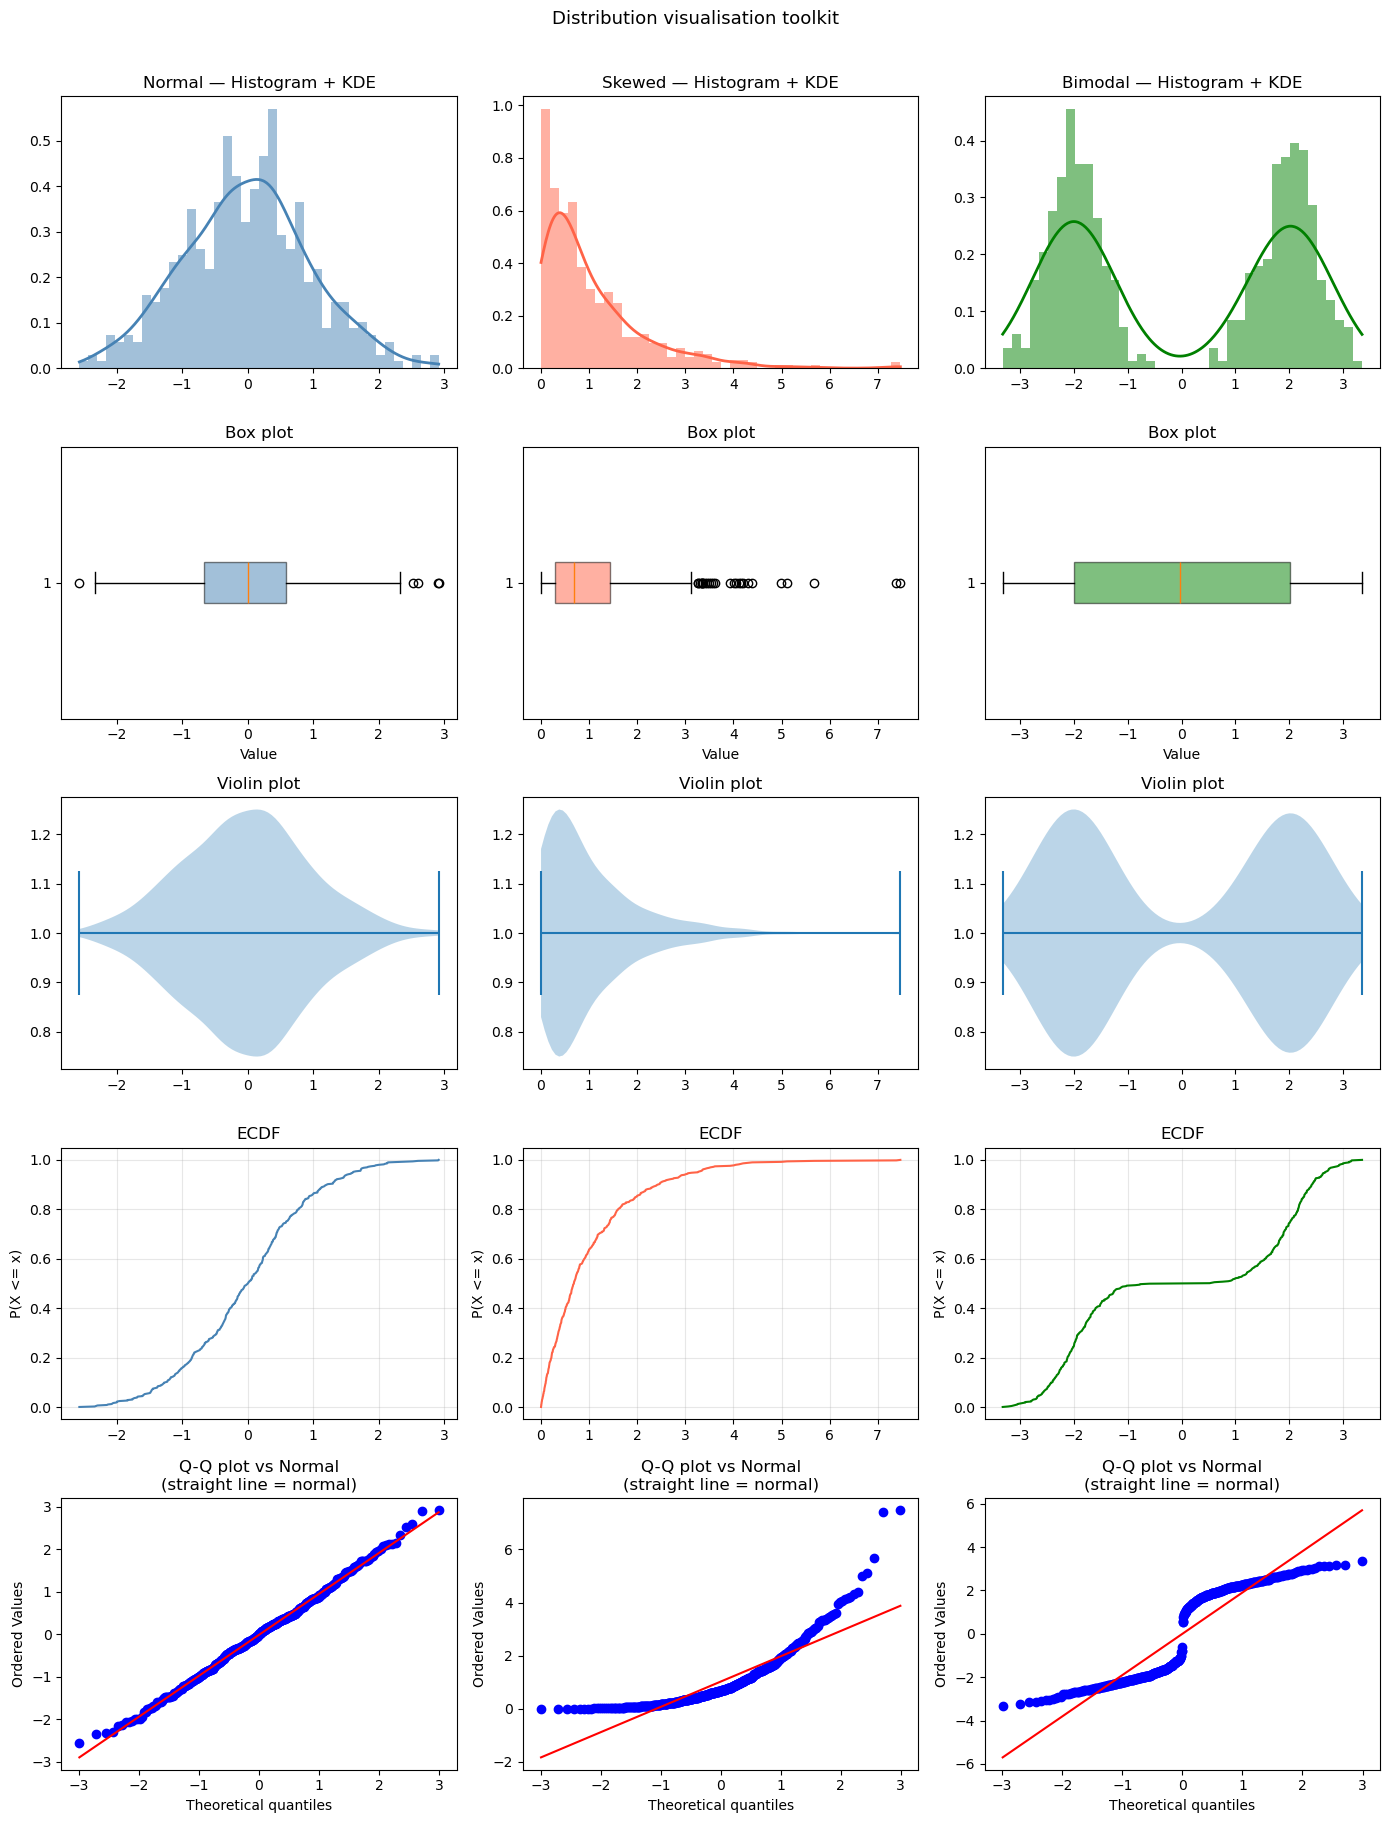

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot, norm
import seaborn as sns

rng = np.random.default_rng(42)
data_normal  = rng.normal(0, 1, 500)
data_skewed  = rng.exponential(1, 500)
data_bimodal = np.concatenate([rng.normal(-2, 0.5, 250), rng.normal(2, 0.5, 250)])

datasets = [('Normal',  data_normal, 'steelblue'),
            ('Skewed',  data_skewed, 'tomato'),
            ('Bimodal', data_bimodal, 'green')]

fig, axes = plt.subplots(5, 3, figsize=(14, 18))

for col, (name, data, color) in enumerate(datasets):
    # Histogram + KDE
    axes[0, col].hist(data, bins=40, density=True, alpha=0.5, color=color)
    x = np.linspace(data.min(), data.max(), 300)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    axes[0, col].plot(x, kde(x), color=color, linewidth=2)
    axes[0, col].set_title(f'{name} — Histogram + KDE')

    # Box plot
    axes[1, col].boxplot(data, vert=False, patch_artist=True,
                          boxprops=dict(facecolor=color, alpha=0.5))
    axes[1, col].set_title('Box plot')
    axes[1, col].set_xlabel('Value')

    # Violin plot
    axes[2, col].violinplot(data, vert=False)
    axes[2, col].set_title('Violin plot')

    # ECDF
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(data)+1) / len(data)
    axes[3, col].plot(sorted_data, ecdf, color=color, linewidth=1.5)
    axes[3, col].set_title('ECDF')
    axes[3, col].set_ylabel('P(X <= x)')
    axes[3, col].grid(True, alpha=0.3)

    # Q-Q plot (vs normal)
    probplot(data, dist='norm', plot=axes[4, col])
    axes[4, col].set_title(f'Q-Q plot vs Normal\n(straight line = normal)')

plt.suptitle('Distribution visualisation toolkit', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Q29e: Що таке тест Колмогорова-Смірнова (KS)?

KS-тест відповідає на питання: **чи однакові два розподіли?**

Він обчислює **D-статистику** = максимальна абсолютна різниця між двома емпіричними ФРЙ:

```
D = max |F₁(x) − F₂(x)|
```

- Мале D → розподіли схожі
- p-value < 0.05 → розподіли **значуще відрізняються**

**Застосування в МН:**
- **Виявлення дрейфу даних:** чи відрізняється виробничий розподіл від навчального?
- **Невідповідність навч./тест.:** чи спрацювала стратифікація?
- **Перевірка ознак:** чи новий пакет даних з тієї ж генеральної сукупності?

Два варіанти:
- **Однова-вибіркова:** порівняти дані з теоретичним розподілом (наприклад, чи нормальний?)
- **Двовибіркова:** порівняти два набори даних


One-sample KS (vs Normal):
  Normal data:  D=0.0731, p=0.0768  -> SAME dist
  Skewed data:  D=0.1608, p=0.0000  -> DIFFERENT

Two-sample KS (train vs test):
  No drift:    D=0.0540, p=0.7825  -> OK
  With drift:  D=0.2790, p=0.0000  -> DRIFT DETECTED!


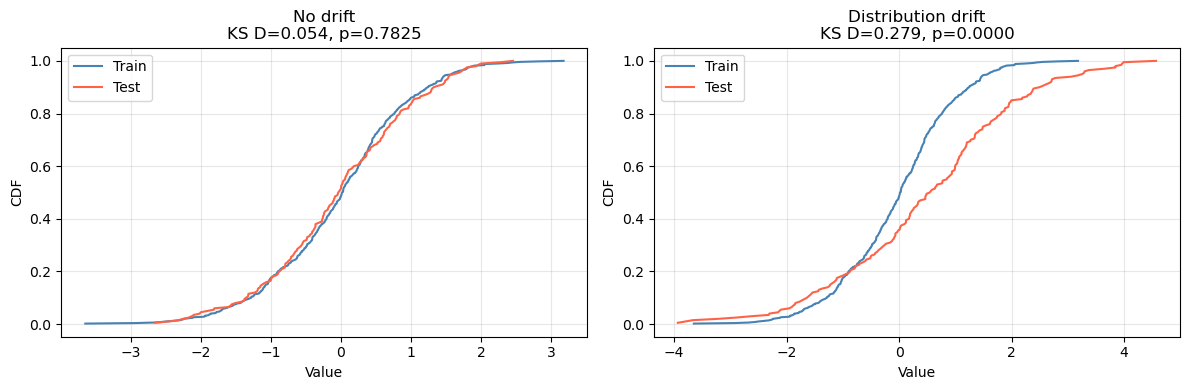

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, kstest, norm

rng = np.random.default_rng(42)

# ── One-sample KS: is data normally distributed? ──────────────────────────────
normal_data = rng.normal(0, 1, 300)
skewed_data = rng.exponential(1, 300)

stat_n, p_n = kstest(normal_data, 'norm', args=(0, 1))
stat_s, p_s = kstest(skewed_data, 'norm', args=(1, 1))
print('One-sample KS (vs Normal):')
print(f'  Normal data:  D={stat_n:.4f}, p={p_n:.4f}  -> {"SAME dist" if p_n > 0.05 else "DIFFERENT"}')
print(f'  Skewed data:  D={stat_s:.4f}, p={p_s:.4f}  -> {"SAME dist" if p_s > 0.05 else "DIFFERENT"}')

# ── Two-sample KS: train vs test distribution (drift example) ────────────────
train = rng.normal(0, 1, 500)
test_ok   = rng.normal(0, 1, 200)        # same distribution
test_drift = rng.normal(0.5, 1.5, 200)  # shifted + wider (drift!)

stat_ok,    p_ok    = ks_2samp(train, test_ok)
stat_drift, p_drift = ks_2samp(train, test_drift)
print('\nTwo-sample KS (train vs test):')
print(f'  No drift:    D={stat_ok:.4f}, p={p_ok:.4f}  -> {"OK" if p_ok > 0.05 else "DRIFT DETECTED!"}')
print(f'  With drift:  D={stat_drift:.4f}, p={p_drift:.4f}  -> {"OK" if p_drift > 0.05 else "DRIFT DETECTED!"}')

# Visualise the D-statistic
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, test, stat, p, title in [
        (axes[0], test_ok,    stat_ok,    p_ok,    'No drift'),
        (axes[1], test_drift, stat_drift, p_drift, 'Distribution drift')]:
    for arr, label, color in [(train, 'Train', 'steelblue'), (test, 'Test', 'tomato')]:
        s = np.sort(arr)
        ax.plot(s, np.arange(1, len(s)+1)/len(s), label=label, color=color, linewidth=1.5)
    ax.set_title(f'{title}\nKS D={stat:.3f}, p={p:.4f}')
    ax.set_xlabel('Value')
    ax.set_ylabel('CDF')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Q29f: Що таке дивергенція Куллбека-Лейблера (KL)?

KL-дивергенція вимірює, **наскільки розподіл Q відрізняється від еталонного P**:

```
KL(P || Q) = Σ P(x) · log( P(x) / Q(x) )   ← дискретний
           = ∫ p(x) · log( p(x) / q(x) ) dx  ← неперервний
```

- KL = 0 → однакові розподіли
- KL > 0 → Q відрізняється від P; більше = більша різниця
- **Несиметрична:** KL(P‖Q) ≠ KL(Q‖P)

**Порівняння з KS-тестом:**
| | KS-тест | KL-дивергенція |
|---|---|---|
| Результат | p-значення (значущість) | Число (величина) |
| Симетрична | Так | Ні |
| Використання | Статистичний тест | Порівняння / моніторинг розподілів |

**Застосування в МН:** моніторинг дрейфу даних, функція втрат VAE, порівняння передбаченого та реального розподілів.


Discrete KL divergence KL(P || Q):
  Q1 (identical)    : KL(P||Q)=0.0000  KL(Q||P)=0.0000  <- asymmetry
  Q2 (slight diff)  : KL(P||Q)=0.0340  KL(Q||P)=0.0353  <- asymmetry
  Q3 (very diff)    : KL(P||Q)=0.8281  KL(Q||P)=1.0443  <- asymmetry

Continuous KL between Gaussians:
  KL(N(0,1) || N(0,1)): 0.0000  — Same N(0,1)
  KL(N(0,1) || N(1,1)): 0.5000  — Shifted N(1,1)
  KL(N(0,1) || N(0,2)): 0.3181  — Wider N(0,2)
  KL(N(0,1) || N(2,3)): 0.8764  — Very different N(2,3)


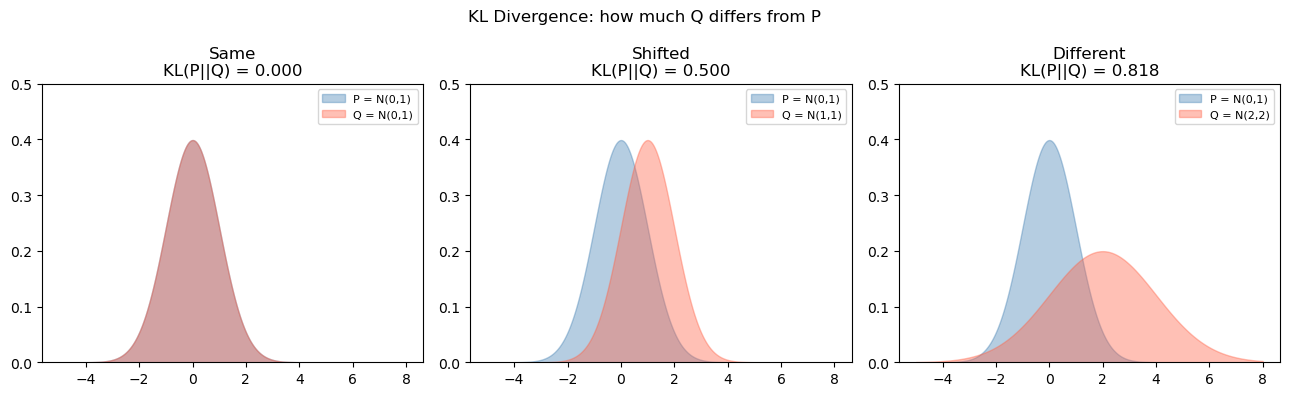

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy as scipy_entropy
from scipy.special import kl_div

# ── Discrete KL divergence ───────────────────────────────────────────────────
P = np.array([0.4, 0.3, 0.2, 0.1])  # reference (true distribution)
Q1 = np.array([0.4, 0.3, 0.2, 0.1])  # identical
Q2 = np.array([0.3, 0.3, 0.3, 0.1])  # slightly different
Q3 = np.array([0.1, 0.1, 0.1, 0.7])  # very different

print('Discrete KL divergence KL(P || Q):')
for label, Q in [('Q1 (identical)', Q1), ('Q2 (slight diff)', Q2), ('Q3 (very diff)', Q3)]:
    kl = scipy_entropy(P, Q)   # scipy entropy(P, Q) = KL(P||Q)
    kl_rev = scipy_entropy(Q, P)
    print(f'  {label:18s}: KL(P||Q)={kl:.4f}  KL(Q||P)={kl_rev:.4f}  <- asymmetry')

# ── Continuous KL divergence between Gaussians ───────────────────────────────
# KL(N(mu1,s1) || N(mu2,s2)) = log(s2/s1) + (s1² + (mu1-mu2)²)/(2*s2²) - 0.5
def kl_gaussians(mu1, s1, mu2, s2):
    return np.log(s2/s1) + (s1**2 + (mu1-mu2)**2) / (2*s2**2) - 0.5

print('\nContinuous KL between Gaussians:')
for mu2, s2, label in [(0, 1, 'Same N(0,1)'),
                        (1, 1, 'Shifted N(1,1)'),
                        (0, 2, 'Wider N(0,2)'),
                        (2, 3, 'Very different N(2,3)')]:
    kl = kl_gaussians(0, 1, mu2, s2)
    print(f'  KL(N(0,1) || N({mu2},{s2})): {kl:.4f}  — {label}')

# ── Visualise ─────────────────────────────────────────────────────────────────
x = np.linspace(-5, 8, 500)
from scipy.stats import norm
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ref = norm.pdf(x, 0, 1)
for ax, (mu, s, label) in zip(axes, [(0,1,'Same'), (1,1,'Shifted'), (2,2,'Different')]):
    q = norm.pdf(x, mu, s)
    ax.fill_between(x, ref, alpha=0.4, color='steelblue', label='P = N(0,1)')
    ax.fill_between(x, q,   alpha=0.4, color='tomato',    label=f'Q = N({mu},{s})')
    kl = kl_gaussians(0, 1, mu, s)
    ax.set_title(f'{label}\nKL(P||Q) = {kl:.3f}')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 0.5)
plt.suptitle('KL Divergence: how much Q differs from P')
plt.tight_layout()
plt.show()


---
# 9. Просунуті теми

## Q30: Що таке PCA (Аналіз головних компонент)?

PCA знаходить напрямки (головні компоненти) максимальної дисперсії в даних і проєктує дані на них. Він:

1. **Зменшує розмірність** — зберігає K компонент замість усіх ознак
2. **Видаляє скорельовані ознаки** — компоненти ортогональні за побудовою
3. **Допомагає у візуалізації** — проєкція у 2D для відображення кластерів

`explained_variance_ratio_` показує, яку частку дисперсії захоплює кожна компонента.


Explained variance ratio: [0.443 0.19 ]
Together: 63.2% of variance


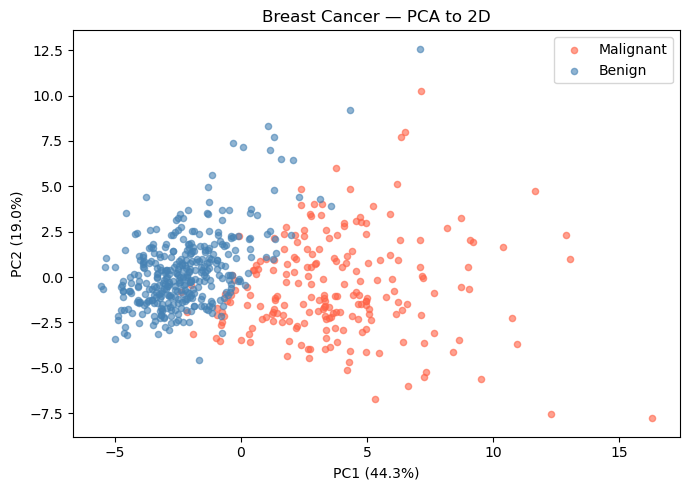

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cancer)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_.round(3))
print(f'Together: {pca.explained_variance_ratio_.sum():.1%} of variance')

plt.figure(figsize=(7, 5))
for cls, color, label in [(0, 'tomato', 'Malignant'), (1, 'steelblue', 'Benign')]:
    mask = y_cancer == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label, alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Breast Cancer — PCA to 2D')
plt.legend()
plt.tight_layout()
plt.show()

## Q30b: Що таке SVD (Розклад на сингулярні значення)?

SVD розкладає будь-яку матрицю **M** (m×n) на три матриці:

```
M = U · Σ · Vᵀ
```

| Матриця | Розмір | Значення |
|---|---|---|
| **U** | m×m | Ліві сингулярні вектори — напрямки в просторі рядків |
| **Σ** | m×n | Діагональна — сингулярні значення (важливість кожного напрямку) |
| **Vᵀ** | n×n | Праві сингулярні вектори — напрямки в просторі стовпців |

**Усічений SVD:** зберігаємо лише K найбільших сингулярних значень → найкраще апроксимування рангу K для M (мінімальна похибка Фробеніуса).

**Зв'язок з PCA:** PCA — це SVD, застосований до матриці центрованих і масштабованих даних. Головні компоненти — це стовпці V.


M shape: (4, 3)
U: (4, 4)   Σ: (4, 3)   Vᵀ: (3, 3)
Singular values: [25.462  1.291  0.   ]
Reconstruction error: 0.0

Rank-K approximation error (Frobenius norm):
  K=1: 1.2907
  K=2: 0.0000
  K=3: 0.0000


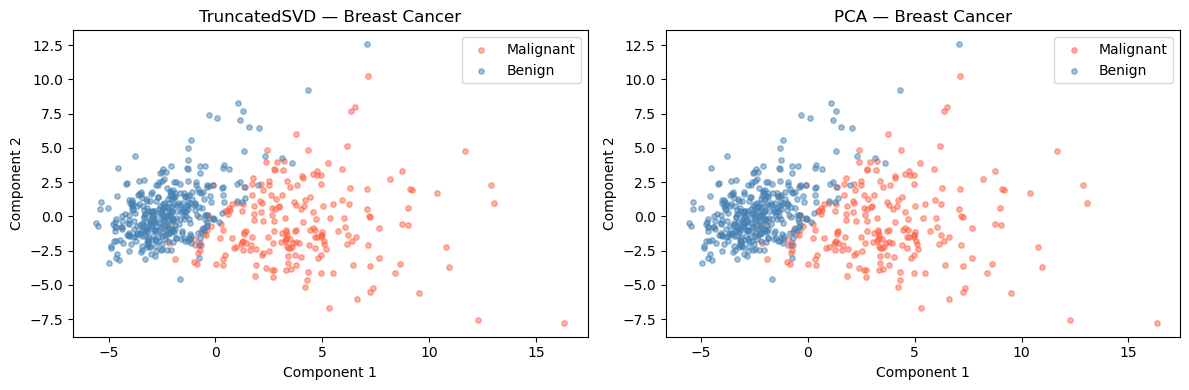

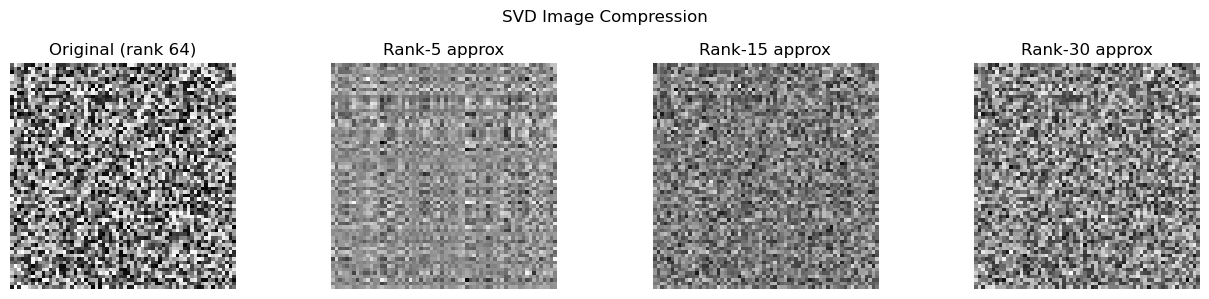

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ── 1. Full SVD ──────────────────────────────────────────────────────────────
M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10, 11, 12]], dtype=float)

U, s, Vt = np.linalg.svd(M, full_matrices=True)
Sigma = np.zeros(M.shape)
np.fill_diagonal(Sigma, s)

print('M shape:', M.shape)
print('U:', U.shape, '  Σ:', Sigma.shape, '  Vᵀ:', Vt.shape)
print('Singular values:', s.round(3))
print('Reconstruction error:', np.linalg.norm(M - U @ Sigma @ Vt).round(10))

# ── 2. Truncated SVD — rank-K approximation ───────────────────────────────────
print('\nRank-K approximation error (Frobenius norm):')
for k in [1, 2, 3]:
    M_approx = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    err = np.linalg.norm(M - M_approx)
    print(f'  K={k}: {err:.4f}')

# ── 3. SVD for dimensionality reduction (vs PCA) ──────────────────────────────
from sklearn.decomposition import TruncatedSVD, PCA

X_scaled = StandardScaler().fit_transform(X_cancer)

# Both should give nearly identical 2-D projections
svd_proj = TruncatedSVD(n_components=2, random_state=42).fit_transform(X_scaled)
pca_proj = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, proj, title in [(axes[0], svd_proj, 'TruncatedSVD'),
                         (axes[1], pca_proj, 'PCA')]:
    for cls, color, label in [(0, 'tomato', 'Malignant'), (1, 'steelblue', 'Benign')]:
        mask = y_cancer == cls
        ax.scatter(proj[mask, 0], proj[mask, 1], c=color, label=label, alpha=0.5, s=15)
    ax.set_title(f'{title} — Breast Cancer')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend()
plt.tight_layout()
plt.show()

# ── 4. Image compression via SVD ─────────────────────────────────────────────
np.random.seed(42)
img = np.random.rand(64, 64)   # synthetic 64×64 "image"
U_img, s_img, Vt_img = np.linalg.svd(img, full_matrices=False)

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (rank 64)')

for ax, k in zip(axes[1:], [5, 15, 30]):
    approx = U_img[:, :k] @ np.diag(s_img[:k]) @ Vt_img[:k, :]
    ax.imshow(approx, cmap='gray')
    ax.set_title(f'Rank-{k} approx')
for ax in axes:
    ax.axis('off')
plt.suptitle('SVD Image Compression')
plt.tight_layout()
plt.show()

## Q31: Що таке важливість ознак і як її використовувати?

Деревовидні моделі (Дерево рішень, Random Forest) обчислюють **важливість ознак** — наскільки кожна ознака зменшує домішок у всіх розбивках.

Це відповідає на питання: *які ознаки насправді важливі?*

Застосування:
- Видалити неважливі ознаки для спрощення моделі
- Зрозуміти, що рухає передбаченнями
- Виявити витік даних (підозріло висока важливість)


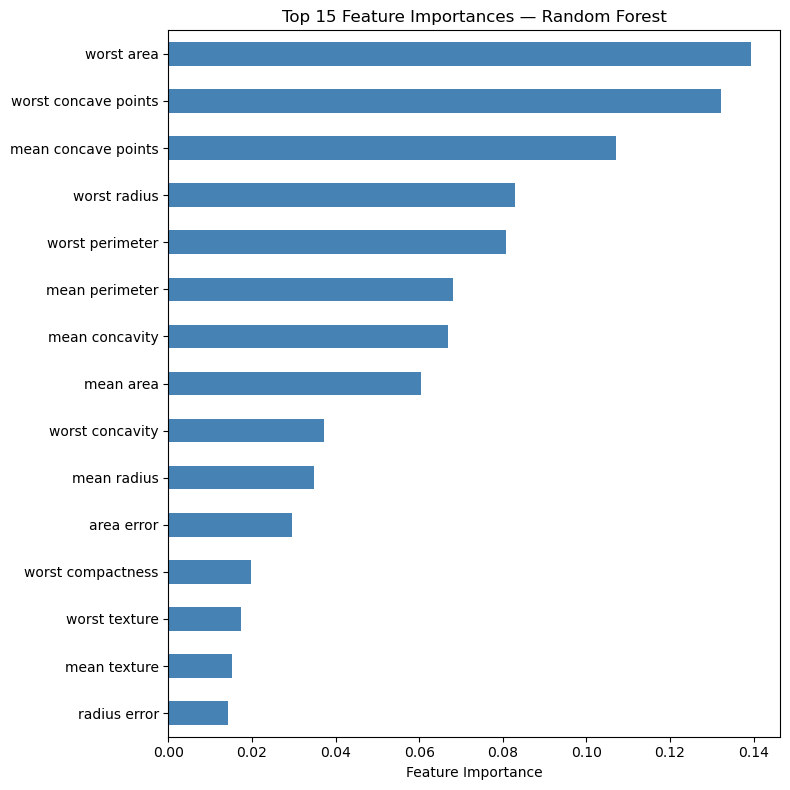

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_cancer, y_cancer)

importances = pd.Series(rf.feature_importances_, index=X_cancer.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importances.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

## Q32: Що таке кластеризація K-Means?

K-Means розбиває дані на K кластерів ітераційно:
1. Призначити кожну точку найближчому центроїду
2. Перерахувати центроїди як середнє призначених точок
3. Повторювати до зупинки центроїдів

**Вибір K:** використовуйте **метод ліктя** — будуйте графік інерції (сума квадратичних відстаней до найближчого центроїду) проти K і шукайте місце, де зменшення сповільнюється.


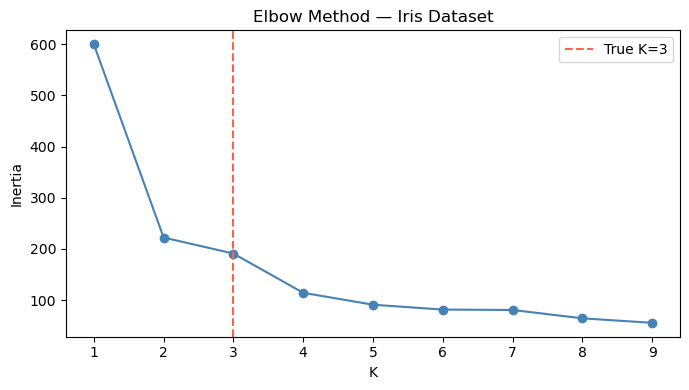

In [46]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_iris)

inertias = []
ks = range(1, 10)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(ks, inertias, marker='o', color='steelblue')
plt.axvline(3, color='tomato', linestyle='--', label='True K=3')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method — Iris Dataset')
plt.legend()
plt.tight_layout()
plt.show()

## Q33: Як систематично порівнювати кілька моделей?

Запустіть одне і те саме налаштування крос-валідації на всіх моделях і порівняйте mean ± std. Відкладену тестову вибірку використовуйте лише один раз наприкінці для переможця.


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    'KNN (k=7)':          Pipeline([('scl', StandardScaler()), ('m', KNeighborsClassifier(n_neighbors=7))]),
    'Decision Tree':      DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression':Pipeline([('scl', StandardScaler()), ('m', LogisticRegression(max_iter=1000))]),
    'Naive Bayes':        GaussianNB(),
    'SVM (rbf)':          Pipeline([('scl', StandardScaler()), ('m', SVC(kernel='rbf', random_state=42))]),
}

print(f'{"Model":25s}  {"CV Mean":>8}  {"CV Std":>7}')
print('-' * 45)
for name, model in models.items():
    s = cross_val_score(model, X_cancer, y_cancer, cv=5, scoring='accuracy')
    print(f'{name:25s}  {s.mean():.4f}    ±{s.std():.4f}')

Model                       CV Mean   CV Std
---------------------------------------------
KNN (k=7)                  0.9701    ±0.0089
Decision Tree              0.9191    ±0.0180


Random Forest              0.9561    ±0.0228
Logistic Regression        0.9807    ±0.0065
Naive Bayes                0.9385    ±0.0146
SVM (rbf)                  0.9736    ±0.0147


## Q34: Що таке витік даних і як його запобігти?

Витік даних відбувається, коли інформація з тестової вибірки (або майбутніх даних) впливає на навчання — роблячи показники моделі кращими, ніж вони є насправді.

**Поширені джерела:**
1. Навчання масштабувальника на всіх даних до розбивки
2. Імпутація пропусків зі статистиками всього набору
3. Конструювання ознак з використанням цільових значень
4. Часові ряди: використання майбутніх даних для передбачення минулого

**Профілактика: завжди використовуйте Pipeline.** `cross_val_score(pipeline, ...)` навчає передобробку свіжо на навчальних даних кожного фолду.


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# WRONG: scale before CV — test fold statistics leak into training
X_leaked = StandardScaler().fit_transform(X_cancer)   # fit on ALL data first
score_leaked = cross_val_score(KNeighborsClassifier(n_neighbors=7),
                               X_leaked, y_cancer, cv=5).mean()

# CORRECT: scaler inside pipeline — fitted only on each fold's train split
pipe = Pipeline([('scl', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=7))])
score_correct = cross_val_score(pipe, X_cancer, y_cancer, cv=5).mean()

print(f'Leaked   CV accuracy: {score_leaked:.4f}')
print(f'Correct  CV accuracy: {score_correct:.4f}')
print('(On large, clean datasets the difference is small but the principle is critical)')

Leaked   CV accuracy: 0.9684
Correct  CV accuracy: 0.9701
(On large, clean datasets the difference is small but the principle is critical)


---
# 10. Конструювання ознак

## FE1: Що таке конструювання ознак і чому воно важливе?

Конструювання ознак = створення або перетворення вхідних ознак, щоб модель легше вивчала паттерни.

**Типи перетворень:**
| Техніка | Коли використовувати | Приклад |
|---|---|---|
| **Логарифмічне перетворення** | Правостороннє розподілення | Ціна, дохід, населення |
| **Поліноміальні ознаки** | Нелінійні залежності | x² або x₁·x₂ взаємодія |
| **Бінінг** | Неперервні → категоріальні | Вікові групи: 0-18, 18-35, ... |
| **Відносини ознак** | Предметно-орієнтовані відносини | дохід/витрати, площа/кімнати |
| **Вилучення дати/часу** | Ознаки мітки часу | година_дня, день_тижня |
| **Члени взаємодії** | Комбінований ефект двох ознак | bmi × вік |

**Правило:** добре сконструйована ознака часто перевершує складнішу модель на сирих ознаках.


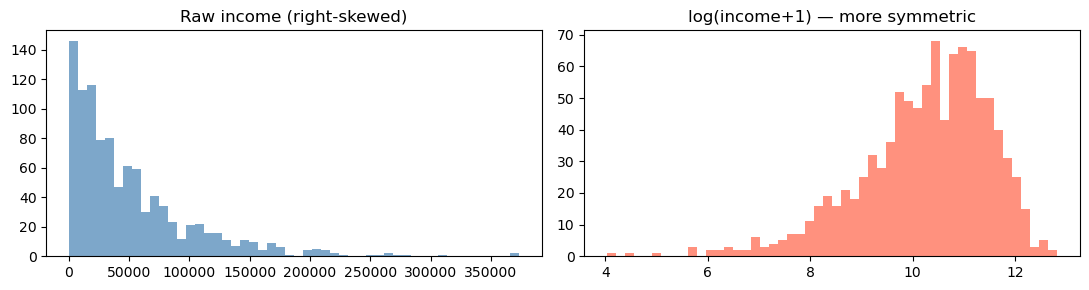

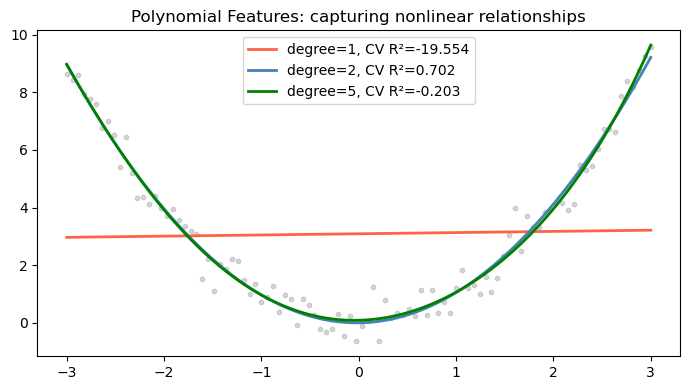

Original features: ['age', 'bmi']
Engineered features: ['age_x_bmi', 'bmi_sq', 'log_bmi']
    age        bmi    age_x_bmi      bmi_sq   log_bmi
0  28.0  22.569029   631.932822  509.361086  3.116579
1  41.0  27.101134  1111.146475  734.471440  3.299576
2  30.0  24.488016   734.640494  599.662950  3.198184
3  22.0  21.747182   478.438002  472.939921  3.079484
4  38.0  21.628938   821.899632  467.810946  3.074032


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(42)

# ── 1. Log transform for skewed data ────────────────────────────────────────
income = rng.exponential(scale=50000, size=1000)
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(income, bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Raw income (right-skewed)')
axes[1].hist(np.log1p(income), bins=50, color='tomato', alpha=0.7)
axes[1].set_title('log(income+1) — more symmetric')
plt.tight_layout()
plt.show()

# ── 2. Polynomial features capture nonlinear patterns ────────────────────────
x_raw = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = x_raw.ravel()**2 + rng.normal(0, 0.5, 100)

results = {}
for degree in [1, 2, 5]:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=degree)),
                     ('lr',   LinearRegression())])
    score = cross_val_score(pipe, x_raw, y_true, cv=5, scoring='r2').mean()
    results[degree] = score

plt.figure(figsize=(7, 4))
for degree, color in [(1,'tomato'),(2,'steelblue'),(5,'green')]:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=degree)), ('lr', LinearRegression())])
    pipe.fit(x_raw, y_true)
    plt.plot(x_raw, pipe.predict(x_raw), color=color, linewidth=2,
             label=f'degree={degree}, CV R²={results[degree]:.3f}')
plt.scatter(x_raw, y_true, alpha=0.3, s=10, color='gray')
plt.title('Polynomial Features: capturing nonlinear relationships')
plt.legend()
plt.tight_layout()
plt.show()

# ── 3. Interaction term example ───────────────────────────────────────────────
df = pd.DataFrame({
    'age':    rng.integers(20, 70, 200).astype(float),
    'bmi':    rng.normal(25, 5, 200),
})
df['age_x_bmi'] = df['age'] * df['bmi']          # interaction feature
df['bmi_sq']    = df['bmi'] ** 2                  # polynomial feature
df['log_bmi']   = np.log(df['bmi'].clip(lower=1)) # log transform

print('Original features:', list(df.columns[:2]))
print('Engineered features:', list(df.columns[2:]))
print(df.head())


## FE2: Як обробляти ознаки дати/часу та циклічне кодування?

Сирі мітки часу треба розкладати на числові ознаки. Деякі ознаки є **циклічними** — година 23 і година 0 є суміжними.
Кодування їх як цілих (0–23) робить 0 і 23 ніби далекими.

**Рішення:** кодувати циклічні ознаки як пару (sin, cos):

```
hour_sin = sin(2π × година / 24)
hour_cos = cos(2π × година / 24)
```

Це зберігає кільцеву структуру.


Features after date decomposition:
        date  month  month_sin  month_cos  is_weekend
0 2024-01-01      1        0.5   0.866025           0
1 2024-01-02      1        0.5   0.866025           0
2 2024-01-03      1        0.5   0.866025           0
3 2024-01-04      1        0.5   0.866025           0
4 2024-01-05      1        0.5   0.866025           0
5 2024-01-06      1        0.5   0.866025           1
6 2024-01-07      1        0.5   0.866025           1


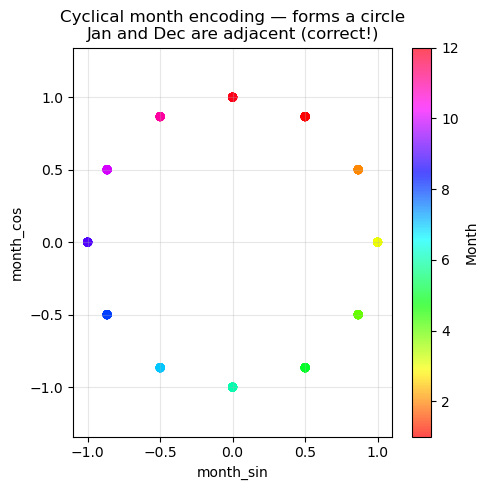

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Date/time feature extraction
dates = pd.date_range('2024-01-01', periods=365, freq='D')
df = pd.DataFrame({'date': dates, 'sales': np.sin(np.arange(365)*2*np.pi/365)*100 + 200})

df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['day_of_week']= df['date'].dt.dayofweek
df['day_of_year']= df['date'].dt.dayofyear
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Cyclical encoding for month (1-12) and day of week (0-6)
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)

print('Features after date decomposition:')
print(df[['date','month','month_sin','month_cos','is_weekend']].head(7))

# Visualise cyclical encoding — months form a circle
plt.figure(figsize=(5, 5))
sc = plt.scatter(df['month_sin'], df['month_cos'],
                  c=df['month'], cmap='hsv', s=30, alpha=0.7)
plt.colorbar(sc, label='Month')
plt.xlabel('month_sin')
plt.ylabel('month_cos')
plt.title('Cyclical month encoding — forms a circle\nJan and Dec are adjacent (correct!)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
# 11. Лінійна алгебра для МН

## LA1: Як дані представляються у вигляді матриці та що таке вектор?

**Набір даних** — це матриця **X** розміром (n_samples × n_features):
- Кожен **рядок** = один зразок (спостереження)
- Кожен **стовпець** = одна ознака

**Вектор** — це одновимірний масив. Кожне передбачення МН — матрична операція:

    y_hat = X @ w + b

Уся передобробка (масштабування, PCA, кодування) є матричним перетворенням.


In [51]:
import numpy as np

X = np.array([[1.2, 0.5, 3.1],
              [2.4, 1.1, 0.8],
              [0.3, 2.2, 1.5],
              [1.8, 0.9, 2.7]])
print('Data matrix X (4 samples x 3 features):')
print(X)
print(f'Shape: {X.shape}')

print(f'\nSample 0 (row vector): {X[0]}')
print(f'Feature 1 (column vector): {X[:, 1]}')

w = np.array([0.5, -0.3, 1.0])  # learned weights
b = 0.1
y_hat = X @ w + b
print(f'\nPredictions y = Xw + b: {y_hat.round(3)}')

Data matrix X (4 samples x 3 features):
[[1.2 0.5 3.1]
 [2.4 1.1 0.8]
 [0.3 2.2 1.5]
 [1.8 0.9 2.7]]
Shape: (4, 3)

Sample 0 (row vector): [1.2 0.5 3.1]
Feature 1 (column vector): [0.5 1.1 2.2 0.9]

Predictions y = Xw + b: [3.65 1.77 1.09 3.43]


## LA2: Що таке евклідовий простір та відстань?

**Евклідовий простір Rⁿ** — n-вимірний простір дійсних чисел, де кожна точка є вектором з n координат. Відстань між двома точками — це L2-норма їх різниці:

    d(a, b) = ||a - b||₂ = sqrt(Σ (a_i - b_i)²)

Саме цю відстань використовує KNN. Масштабування ознак критичне — інакше ознаки з більшими абсолютними значеннями домінують у розрахунку відстані.


In [52]:
import numpy as np
import matplotlib.pyplot as plt

a = np.array([1.0, 2.0])
b = np.array([4.0, 6.0])

d_euclidean = np.linalg.norm(a - b)
d_manhattan = np.linalg.norm(a - b, 1)
print(f'a = {a},  b = {b}')
print(f'Euclidean distance: {d_euclidean:.4f}  (sqrt((4-1)^2 + (6-2)^2))')
print(f'Manhattan distance: {d_manhattan:.4f}  (|4-1| + |6-2|)')

# Why scaling matters for KNN
p1 = np.array([1.0,    1000.0])  # age=1, income=1000
p2 = np.array([1.0,    2000.0])  # age=1, income=2000
p3 = np.array([50.0,   1001.0])  # age=50, income=1001
print('\nWithout scaling:')
print(f'  d(p1, p2) = {np.linalg.norm(p1-p2):.1f}  (differ only in income)')
print(f'  d(p1, p3) = {np.linalg.norm(p1-p3):.1f}  (differ heavily in age)')
print('  KNN would say p1 and p3 are farther apart even though income difference is tiny')

from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform([p1, p2, p3])
print('\nAfter StandardScaler:')
print(f'  d(p1, p2) = {np.linalg.norm(scaled[0]-scaled[1]):.3f}')
print(f'  d(p1, p3) = {np.linalg.norm(scaled[0]-scaled[2]):.3f}')

a = [1. 2.],  b = [4. 6.]
Euclidean distance: 5.0000  (sqrt((4-1)^2 + (6-2)^2))
Manhattan distance: 7.0000  (|4-1| + |6-2|)

Without scaling:
  d(p1, p2) = 1000.0  (differ only in income)
  d(p1, p3) = 49.0  (differ heavily in age)
  KNN would say p1 and p3 are farther apart even though income difference is tiny

After StandardScaler:
  d(p1, p2) = 2.122
  d(p1, p3) = 2.121


## LA3: Що таке ортонормований базис?

Набір векторів утворює **ортонормований базис**, коли:
1. **Ортогональні:** кожна пара перпендикулярна (скалярний добуток = 0)
2. **Нормовані (одинична довжина):** кожен вектор має L2-норму = 1

Чому це важливо в МН:
- Головні компоненти PCA утворюють ортонормований базис простору ознак
- Матриці U та V в SVD є ортонормованими
- Проєкція на ортонормований базис обчислювально дешева: просто скалярний добуток
- Проєкції не перекриваються — кожна компонента захоплює унікальну дисперсію


In [53]:
import numpy as np

# Standard basis of R^3 (canonical example)
e1 = np.array([1., 0., 0.])
e2 = np.array([0., 1., 0.])
e3 = np.array([0., 0., 1.])

print('Standard basis of R^3:')
for i, (u, v) in enumerate([(e1,e2),(e1,e3),(e2,e3)]):
    print(f'  e{i+1} dot e{i+2}: {np.dot(u,v):.1f}  (should be 0 = orthogonal)')
for i, e in enumerate([e1, e2, e3]):
    print(f'  ||e{i+1}|| = {np.linalg.norm(e):.1f}  (should be 1 = unit length)')

# PCA components are orthonormal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

X_iris, _ = load_iris(return_X_y=True)
X_sc = StandardScaler().fit_transform(X_iris)
pca = PCA(n_components=4).fit(X_sc)
V = pca.components_  # shape (4, 4) — each row is a principal component

print('\nPCA components are orthonormal:')
print('  V @ V.T (should be identity):')
print((V @ V.T).round(10))

# Projection: coordinates of data in PC space = just a matrix multiply
X_proj = X_sc @ V.T  # same as pca.transform(X_sc)
print(f'\nProjected data shape: {X_proj.shape}  (150 samples x 4 components)')
print(f'Variance per component: {pca.explained_variance_ratio_.round(3)}')

Standard basis of R^3:
  e1 dot e2: 0.0  (should be 0 = orthogonal)
  e2 dot e3: 0.0  (should be 0 = orthogonal)
  e3 dot e4: 0.0  (should be 0 = orthogonal)
  ||e1|| = 1.0  (should be 1 = unit length)
  ||e2|| = 1.0  (should be 1 = unit length)
  ||e3|| = 1.0  (should be 1 = unit length)

PCA components are orthonormal:
  V @ V.T (should be identity):
[[ 1. -0. -0. -0.]
 [-0.  1.  0.  0.]
 [-0.  0.  1.  0.]
 [-0.  0.  0.  1.]]

Projected data shape: (150, 4)  (150 samples x 4 components)
Variance per component: [0.73  0.229 0.037 0.005]


## LA4: Що таке ранг матриці — і що означає апроксимація рангу K в SVD/PCA?

**Ранг** матриці = кількість лінійно незалежних рядків (або стовпців) = справжня кількість вимірів, які охоплюють дані.

В SVD: `M = U S Vᵀ` де S — діагональна з сингулярними значеннями s₁ ≥ s₂ ≥ ... ≥ sᵣ > 0.
Ранг дорівнює кількості **ненульових сингулярних значень**.

**Апроксимація рангу K** зберігає лише K найбільших сингулярних значень:

    M_K = U[:, :K] @ diag(s[:K]) @ Vᵀ[:K, :]

Це *найближча* матриця рангу K до M (теорема Екарта-Янга).
Кожна збережена компонента захоплює наступний найважливіший напрямок варіації.


Full-rank matrix rank: 3
Rank-deficient matrix rank: 2 (3x3 but rank=2)
Singular values: [15.663323  0.812594  0.      ]  <- last one ~0 confirms rank=2

Rank-K approximation of a 30x15 matrix:
    K   Var explained   Frobenius error
    1          19.0%           19.2218
    3          45.2%           15.8121
    5          63.5%           12.9093
   10          90.7%            6.5057
   15         100.0%            0.0000


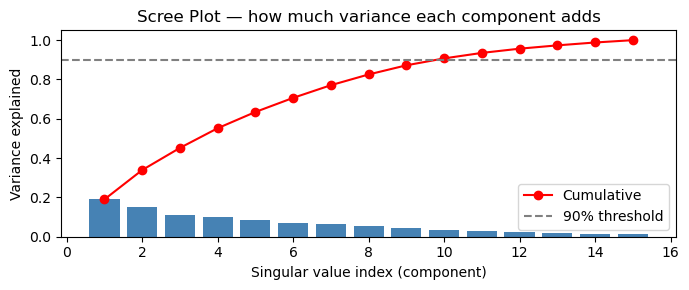

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Matrix rank
A_full = np.array([[1.,0.,0.],[0.,2.,0.],[0.,0.,3.]])
A_rank2 = np.array([[1.,2.,3.],[4.,5.,6.],[5.,7.,9.]])  # row3=row1+row2
print(f'Full-rank matrix rank: {np.linalg.matrix_rank(A_full)}')
print(f'Rank-deficient matrix rank: {np.linalg.matrix_rank(A_rank2)} (3x3 but rank=2)')

U, s, Vt = np.linalg.svd(A_rank2)
print(f'Singular values: {s.round(6)}  <- last one ~0 confirms rank=2')

# Rank-K approximation quality
rng = np.random.default_rng(0)
M = rng.normal(size=(30, 15))
U, s, Vt = np.linalg.svd(M, full_matrices=False)
total_var = (s**2).sum()

print(f'\nRank-K approximation of a 30x15 matrix:')
print(f'  {"K":>3}  {"Var explained":>14}  {"Frobenius error":>16}')
for k in [1, 3, 5, 10, 15]:
    M_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    var = (s[:k]**2).sum() / total_var
    err = np.linalg.norm(M - M_k, 'fro')
    print(f'  {k:>3}  {var:>13.1%}  {err:>16.4f}')

# Scree plot: variance explained by each singular value
var_explained = (s**2) / total_var
plt.figure(figsize=(7, 3))
plt.bar(range(1, len(s)+1), var_explained, color='steelblue')
plt.plot(range(1, len(s)+1), np.cumsum(var_explained), 'ro-', label='Cumulative')
plt.axhline(0.9, color='gray', linestyle='--', label='90% threshold')
plt.xlabel('Singular value index (component)')
plt.ylabel('Variance explained')
plt.title('Scree Plot — how much variance each component adds')
plt.legend()
plt.tight_layout()
plt.show()

## LA5: Ключові матричні операції — скалярний добуток, транспонування, обернена матриця, визначник

| Операція | Код | Використання в МН |
|---|---|---|
| Скалярний добуток | `np.dot(a, b)` | Подібність; основа кожної лінійної моделі |
| Множення матриць | `A @ B` | Застосування перетворень; пакетні передбачення |
| Транспонування | `A.T` | Формула МНК `(XᵀX)⁻¹Xᵀy` |
| Обернена матриця | `np.linalg.inv(A)` | Аналітичний розв'язок МНК |
| Визначник | `np.linalg.det(A)` | Перевірка оборотності (det=0 → сингулярна) |


In [55]:
import numpy as np

a = np.array([1., 2., 3.])
b = np.array([4., 5., 6.])

# Dot product
print(f'a . b = {np.dot(a, b)}  (= 1*4 + 2*5 + 3*6)')
cos_theta = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(f'angle(a, b) = {np.degrees(np.arccos(cos_theta)):.2f} deg')

# Transpose
A = np.array([[1,2,3],[4,5,6]])
print(f'\nA shape {A.shape}  ->  A.T shape {A.T.shape}')

# Inverse
M = np.array([[2., 1.],[1., 3.]])
M_inv = np.linalg.inv(M)
print(f'\nM @ M_inv (identity check):')
print((M @ M_inv).round(10))

# Determinant
print(f'\ndet(M) = {np.linalg.det(M):.4f}  (non-zero -> invertible)')
singular = np.array([[1., 2.],[2., 4.]])  # linearly dependent rows
print(f'det(singular) = {np.linalg.det(singular):.4f}  -> not invertible')

# OLS closed form: w = (X^T X)^-1 X^T y
rng = np.random.default_rng(42)
X_d = rng.normal(size=(50, 2))
y_d = 3*X_d[:,0] - 2*X_d[:,1] + rng.normal(scale=0.1, size=50)
X_b = np.hstack([np.ones((50,1)), X_d])
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_d
print(f'\nOLS w = (X^T X)^-1 X^T y:')
print(f'  intercept={w_ols[0]:.3f}, w1={w_ols[1]:.3f}, w2={w_ols[2]:.3f}')
print(f'  True: intercept=0, w1=3, w2=-2')

a . b = 32.0  (= 1*4 + 2*5 + 3*6)
angle(a, b) = 12.93 deg

A shape (2, 3)  ->  A.T shape (3, 2)

M @ M_inv (identity check):
[[ 1.  0.]
 [-0.  1.]]

det(M) = 5.0000  (non-zero -> invertible)
det(singular) = 0.0000  -> not invertible

OLS w = (X^T X)^-1 X^T y:
  intercept=-0.006, w1=3.010, w2=-2.017
  True: intercept=0, w1=3, w2=-2


## LA6: Що таке власні значення та власні вектори — основа PCA?

Для квадратної матриці **A** **власний вектор** v — це особливий напрямок, який A лише *розтягує*, ніколи не *повертає*:

    A v = λ v

- **v** = власний вектор (напрямок, що зберігається перетворенням)
- **λ** = власне значення (коефіцієнт розтягування)

**У PCA:** обчислюємо коваріаційну матрицю даних, знаходимо її власні вектори. Це і є головні компоненти — напрямки максимальної дисперсії. Більше власне значення = важливіший напрямок.


A: [[3. 1.]
 [1. 3.]]
Eigenvalues:  [4. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

A @ v0 = [2.828427 2.828427]
lv0 * v0 = [2.828427 2.828427]  <- same

A @ v1 = [-1.414214  1.414214]
lv1 * v1 = [-1.414214  1.414214]  <- same

Covariance eigenvalues: [5.89  0.219]
Variance explained: [0.964 0.036]


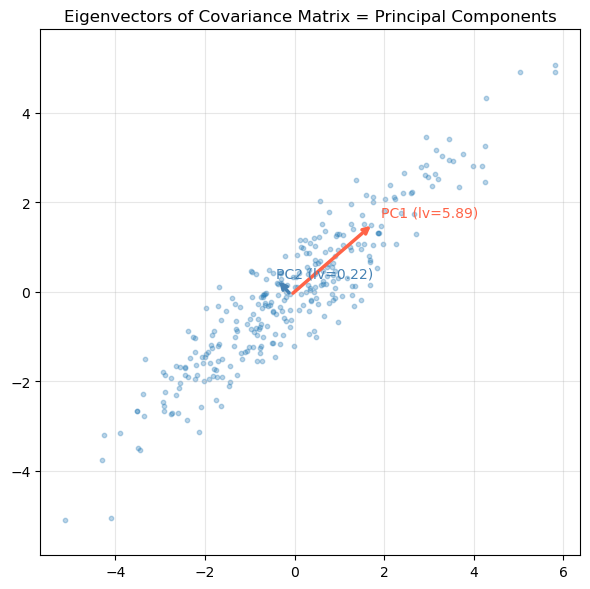

In [56]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[3., 1.],[1., 3.]])
eigenvalues, eigenvectors = np.linalg.eig(A)
print('A:', A)
print(f'Eigenvalues:  {eigenvalues}')
print(f'Eigenvectors (columns):\n{eigenvectors}')

for i in range(2):
    v = eigenvectors[:, i]
    lv = eigenvalues[i]
    print(f'\nA @ v{i} = {(A @ v).round(6)}')
    print(f'lv{i} * v{i} = {(lv * v).round(6)}  <- same')

# PCA via covariance matrix eigenvectors
rng = np.random.default_rng(42)
x1 = rng.normal(0, 2, 300)
x2 = 0.8*x1 + rng.normal(0, 0.6, 300)
X2d = np.column_stack([x1, x2])
cov = np.cov(X2d.T)
evals, evecs = np.linalg.eig(cov)
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]
print(f'\nCovariance eigenvalues: {evals.round(3)}')
print(f'Variance explained: {(evals/evals.sum()).round(3)}')

plt.figure(figsize=(6, 6))
plt.scatter(X2d[:, 0], X2d[:, 1], alpha=0.3, s=10)
origin = X2d.mean(axis=0)
for i in range(2):
    vec = evecs[:, i]
    scale = np.sqrt(evals[i])
    plt.annotate('', xy=origin + scale*vec, xytext=origin,
                 arrowprops=dict(arrowstyle='->', color=['tomato','steelblue'][i], lw=2.5))
    plt.text(*(origin + scale*vec*1.1), f'PC{i+1} (lv={evals[i]:.2f})', fontsize=10,
             color=['tomato','steelblue'][i])
plt.axis('equal')
plt.title('Eigenvectors of Covariance Matrix = Principal Components')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## LA7: Що таке норми векторів і матриць?

**Норма** вимірює «розмір» вектора або матриці.

| Норма | Формула | Назва | Використання |
|---|---|---|---|
| L1 | Σ \|xᵢ\| | Манхеттенська | Штраф Lasso; розріджені сигнали |
| L2 | √(Σ xᵢ²) | Евклідова | Відстань KNN; штраф Ridge |
| L∞ | max \|xᵢ\| | Чебишева | Похибка найгіршого випадку |
| Фробеніуса | √(Σ Aᵢⱼ²) | Матрична L2 | Похибка апроксимації SVD |

L1-норми заохочують **розрідженість** (кути обмежувальної множини лежать на осях).
L2-норми заохочують **малі, але ненульові** ваги.


v = [ 3. -4.  0.  1.]
L1 norm: 8.0000  = |3|+|-4|+|0|+|1|
L2 norm: 5.0990  = sqrt(9+16+0+1)
Linf norm: 4.0000  = max(3,4,0,1)
Frobenius norm: 5.4772  = sqrt(1+4+9+16)


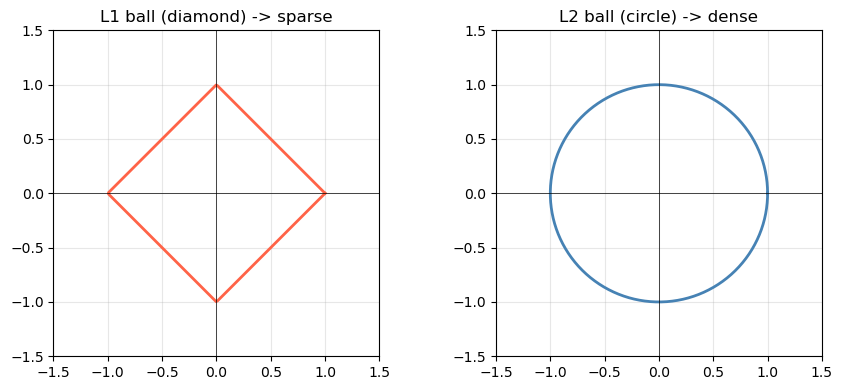

In [57]:
import numpy as np
import matplotlib.pyplot as plt

v = np.array([3., -4., 0., 1.])
print(f'v = {v}')
print(f'L1 norm: {np.linalg.norm(v, 1):.4f}  = |3|+|-4|+|0|+|1|')
print(f'L2 norm: {np.linalg.norm(v, 2):.4f}  = sqrt(9+16+0+1)')
print(f'Linf norm: {np.linalg.norm(v, np.inf):.4f}  = max(3,4,0,1)')

A = np.array([[1.,2.],[3.,4.]])
print(f'Frobenius norm: {np.linalg.norm(A, "fro"):.4f}  = sqrt(1+4+9+16)')

# L1 vs L2 unit balls in 2D
theta = np.linspace(0, 2*np.pi, 500)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, p, title, color in [
        (axes[0], 1, 'L1 ball (diamond) -> sparse', 'tomato'),
        (axes[1], 2, 'L2 ball (circle) -> dense',   'steelblue')]:
    pts = np.column_stack([np.cos(theta), np.sin(theta)])
    r = 1.0 / (np.sum(np.abs(pts)**p, axis=1)**(1/p) + 1e-12)
    pts_s = pts * r[:, None]
    ax.plot(pts_s[:, 0], pts_s[:, 1], color=color, linewidth=2)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## LA8: Що таке метод найменших квадратів і як він виводиться?

**Мета:** знайти ваги **w**, що мінімізують суму квадратів помилок між передбаченнями та цільовими значеннями:

    Втрати(w) = ||Xw - y||₂² = (Xw - y)ᵀ (Xw - y)

**Виведення:** беремо градієнт, прирівнюємо до нуля:

    dВтрати/dw = 2 Xᵀ (Xw - y) = 0
    Xᵀ X w = Xᵀ y
    w = (XᵀX)⁻¹ Xᵀy     ← нормальні рівняння

Це **МНК (метод найменших квадратів)** — єдиний глобальний мінімум, коли X має повний ранг стовпців.

Якщо X близька до сингулярної (скорельовані ознаки), `(XᵀX)⁻¹` стає нестабільним.
Ridge-регресія додає `alpha * I`: `w = (XᵀX + αI)⁻¹ Xᵀy`.


OLS via normal equations:
  intercept = 0.8920  (true: 1.0)
  slope     = 2.0724  (true: 2.0)

sklearn LinearRegression: intercept=0.8920, slope=2.0724

Ridge (alpha=1) via closed form: intercept=0.8721, slope=2.0734


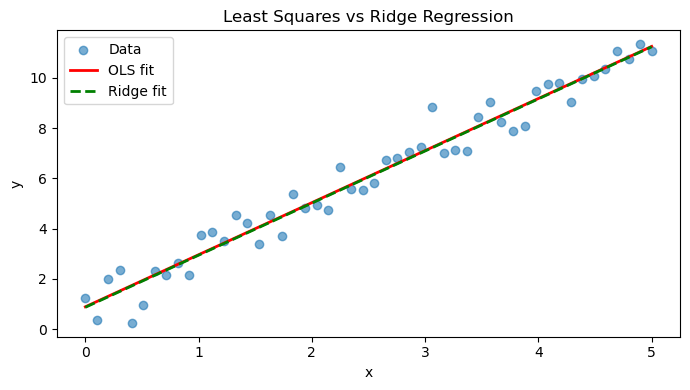

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
rng = np.random.default_rng(42)
x = np.linspace(0, 5, 50)
y = 2.0 * x + 1.0 + rng.normal(scale=0.8, size=50)

# OLS via normal equations
X_b = np.column_stack([np.ones_like(x), x])  # add bias column
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print(f'OLS via normal equations:')
print(f'  intercept = {w_ols[0]:.4f}  (true: 1.0)')
print(f'  slope     = {w_ols[1]:.4f}  (true: 2.0)')

# Verify: same as sklearn
from sklearn.linear_model import LinearRegression, Ridge
lr_sk = LinearRegression().fit(x.reshape(-1,1), y)
print(f'\nsklearn LinearRegression: intercept={lr_sk.intercept_:.4f}, slope={lr_sk.coef_[0]:.4f}')

# Ridge = (X^T X + alpha I)^-1 X^T y
alpha = 1.0
n_feat = X_b.shape[1]
w_ridge = np.linalg.inv(X_b.T @ X_b + alpha * np.eye(n_feat)) @ X_b.T @ y
print(f'\nRidge (alpha=1) via closed form: intercept={w_ridge[0]:.4f}, slope={w_ridge[1]:.4f}')

# Plot fit
x_line = np.linspace(0, 5, 100)
plt.figure(figsize=(7, 4))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x_line, w_ols[0] + w_ols[1]*x_line, 'r-', linewidth=2, label='OLS fit')
plt.plot(x_line, w_ridge[0] + w_ridge[1]*x_line, 'g--', linewidth=2, label='Ridge fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Squares vs Ridge Regression')
plt.legend()
plt.tight_layout()
plt.show()

## LA9: МНК проти Градієнтного спуску — що коли використовувати?

Обидва вирішують одну задачу лінійної регресії, але різними способами:

| | МНК (нормальні рівняння) | Градієнтний спуск |
|---|---|---|
| **Метод** | Точний аналітичний розв'язок | Ітераційне наближення |
| **Формула** | w = (XᵀX)⁻¹Xᵀy | w ← w − α∇Втрати |
| **Швидкість (малі дані)** | Швидкий | Повільніший (багато ітерацій) |
| **Швидкість (великі дані)** | Повільний — O(p³) для інверсії | Швидкий — O(n·p) за крок |
| **Гіперпараметри** | Відсутні | Швидкість навчання α, кількість ітерацій |
| **Чисельна стійкість** | Проблеми при сингулярному XᵀX | Завжди застосовний |
| **Узагальнюється на** | Лише лінійні моделі | Будь-яка диференційована функція втрат (нейронні мережі!) |

**Правило:** використовуйте МНК при малій кількості ознак (< ~10k). Використовуйте градієнтний спуск/SGD для великих задач.


n=   500, p=  5:  OLS    0.2ms MSE=0.2556 | SGD    5.0ms MSE=0.2556


n= 10000, p=100:  OLS  214.6ms MSE=0.2454 | SGD   45.9ms MSE=0.2504


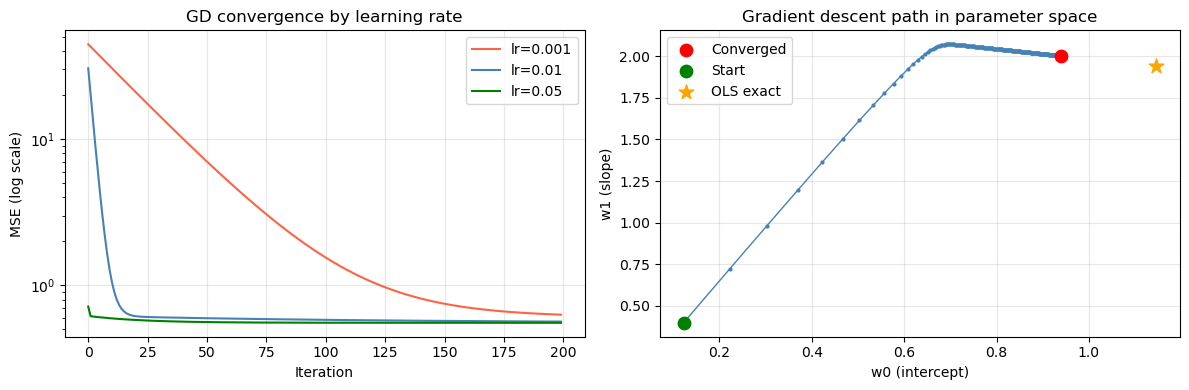

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

rng = np.random.default_rng(42)

for n, p in [(500, 5), (10_000, 100)]:
    X = rng.normal(size=(n, p))
    w_true = rng.normal(size=p)
    y = X @ w_true + rng.normal(scale=0.5, size=n)

    # OLS
    t0 = time.perf_counter()
    X_b = np.hstack([np.ones((n,1)), X])
    w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    t_ols = time.perf_counter() - t0

    # SGD
    t0 = time.perf_counter()
    sgd = Pipeline([('scl', StandardScaler()),
                    ('sgd', SGDRegressor(max_iter=1000, random_state=42))])
    sgd.fit(X, y)
    t_sgd = time.perf_counter() - t0

    ols_err = np.mean((X @ w_ols[1:] + w_ols[0] - y)**2)
    sgd_err = np.mean((sgd.predict(X) - y)**2)

    print(f'n={n:6d}, p={p:3d}:  OLS {t_ols*1000:6.1f}ms MSE={ols_err:.4f} | '
          f'SGD {t_sgd*1000:6.1f}ms MSE={sgd_err:.4f}')

# ── Visualise gradient descent convergence ───────────────────────────────────
rng2 = np.random.default_rng(0)
x1d = rng2.uniform(0, 5, 80)
y1d = 2*x1d + 1 + rng2.normal(0, 0.8, 80)
X1d = np.column_stack([np.ones_like(x1d), x1d])

def gd_path(X, y, lr, n_iter=200):
    w = np.zeros(X.shape[1])
    losses, ws = [], []
    for _ in range(n_iter):
        grad = (2/len(y)) * X.T @ (X @ w - y)
        w = w - lr * grad
        losses.append(np.mean((X @ w - y)**2))
        ws.append(w.copy())
    return losses, ws

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
for lr, color in [(0.001,'tomato'),(0.01,'steelblue'),(0.05,'green')]:
    losses, _ = gd_path(X1d, y1d, lr)
    axes[0].plot(losses, color=color, label=f'lr={lr}')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE (log scale)')
axes[0].set_title('GD convergence by learning rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Weight trajectory (parameter space)
_, ws = gd_path(X1d, y1d, 0.01)
ws = np.array(ws)
axes[1].plot(ws[:, 0], ws[:, 1], 'o-', markersize=2, linewidth=1, color='steelblue')
axes[1].scatter([ws[-1,0]], [ws[-1,1]], color='red', s=80, zorder=5, label='Converged')
axes[1].scatter([ws[0,0]],  [ws[0,1]],  color='green', s=80, zorder=5, label='Start')
w_ols_1d = np.linalg.inv(X1d.T@X1d)@X1d.T@y1d
axes[1].scatter([w_ols_1d[0]], [w_ols_1d[1]], color='orange', s=120, zorder=5,
                marker='*', label=f'OLS exact')
axes[1].set_xlabel('w0 (intercept)')
axes[1].set_ylabel('w1 (slope)')
axes[1].set_title('Gradient descent path in parameter space')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Зведена таблиця

| Тема | Ключова концепція | Розглядається в |
|---|---|---|
| Розбивка train-test | Чесна оцінка | Q2 |
| Крос-валідація | Стабільна оцінка | Q3 |
| Типовий пайплайн МН | EDA→ознаки→обробка→тюнінг→оцінка | Q3b |
| Пропущені значення | SimpleImputer | Q4 |
| Масштабування | StandardScaler / MinMaxScaler | Q5 |
| Нормалізація | Min-Max vs Z-оцінка vs L2 | Q5b |
| Кореляція Пірсона/Спірмена | Відбір ознак, кореляція з ціллю | Q5c |
| Кодування | OneHotEncoder | Q6 |
| Pipeline | Запобігання витоку | Q7, Q34 |
| ColumnTransformer | Змішані типи даних | Q8 |
| KNN | Голосування за відстанню | Q9 |
| Дерево рішень | Рекурсивне розбиття | Q10 |
| Джині vs Ентропія | Домішок вузла, інформаційний приріст | Q10b |
| Random Forest | Ансамбль / бегінг | Q11 |
| Логістична регресія | Сигмоїд / лінійна межа | Q12 |
| Наївний Байєс | Байєс + незалежність | Q13 |
| SVM | Гіперплощина максимального зазору | Q14 |
| Лінійна регресія (МНК) | Нормальні рівняння | Q15 |
| Градієнтний спуск | Ітераційна оптимізація | Q16 |
| Регуляризація (L1/L2) | Ridge, Lasso | Q17 |
| Ridge vs Lasso геометрія | Шляхи коефіцієнтів, розрідженість | Q17b |
| Матриця плутанини | TP/TN/FP/FN | Q18 |
| Accuracy/Precision/Recall/F1 | Метрики класифікації | Q19 |
| ROC-AUC | Ранжування без порогу | Q20 |
| Гід по метриках класифікації | Коли і як інтерпретувати | Q20b |
| MAE / MSE / RMSE | Похибка регресії | Q21 |
| R² | Пояснена дисперсія | Q22 |
| Гід по метриках регресії | Розрив MAE-RMSE, залишки | Q22b |
| Параметри vs Гіперпараметри | Що вивчає модель vs що задаєте ви | Q23 |
| Перенавчання / недонавчання | Компроміс зміщення-дисперсії | Q24 |
| GridSearchCV | Вичерпний тюнінг | Q25 |
| RandomizedSearchCV | Ефективний тюнінг великих сіток | Q26 |
| ФМЙ / ФЩЙ / ФРЙ | Розподіли ймовірностей | Q27 |
| Теорема Байєса | Апріорна → апостеріорна | Q28 |
| MLE | Підгонка розподілів до даних | Q29 |
| Дисперсія та розкид | σ², std, CV | Q29b |
| Центральна гранична теорема | Середні вибірок → нормальний | Q29c |
| Візуалізація розподілів | Гістограма, KDE, box, violin, ECDF, Q-Q | Q29d |
| KS-тест | Однаковість розподілів, дрейф | Q29e |
| KL-дивергенція | Відстань між розподілами | Q29f |
| PCA | Зниження розмірності | Q30 |
| SVD | Матричний розклад | Q30b |
| Важливість ознак | Які ознаки важливі | Q31 |
| K-Means | Кластеризація без учителя | Q32 |
| Порівняння моделей | CV по всіх моделях | Q33 |
| Витік даних | Pipeline запобігає | Q34 |
| Конструювання ознак | Log, полінов., взаємодії, циклічне | FE1-FE2 |
| Дані як матриця | Рядки=зразки, стовпці=ознаки | LA1 |
| Евклідовий простір і відстань | L2-норма, важливість масштабування | LA2 |
| Ортонормований базис | Компоненти PCA, проєкції | LA3 |
| Ранг матриці та ранг-K | Апроксимація SVD | LA4 |
| Матричні операції | скалярний добуток, @, транспон., обернена, det | LA5 |
| Власні значення/вектори | Геометрична основа PCA | LA6 |
| Норми (L1/L2/Фробеніуса) | Регуляризація, відстані | LA7 |
| Метод найменших квадратів | Нормальні рівняння, Ridge | LA8 |
| МНК vs Градієнтний спуск | Складність, коли використовувати | LA9 |
